EDA COMPLETE ANALYSIS PIPELINE

CARDIOVASCULAR DISEASE DATASET - COMPLETE ANALYSIS
DATASET INFORMATION
Shape: 70,000 rows, 13 columns

Columns and data types:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

First 5 rows:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0     

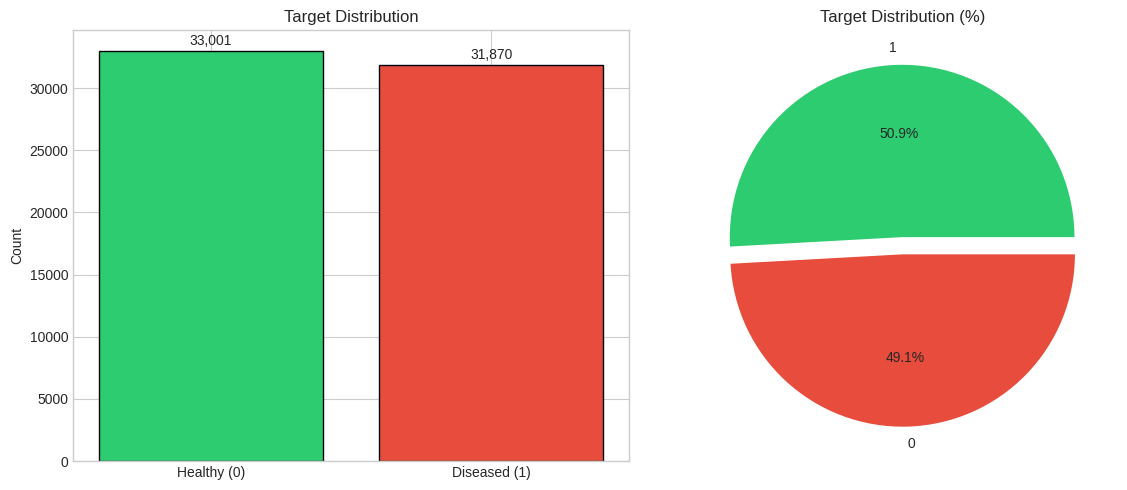

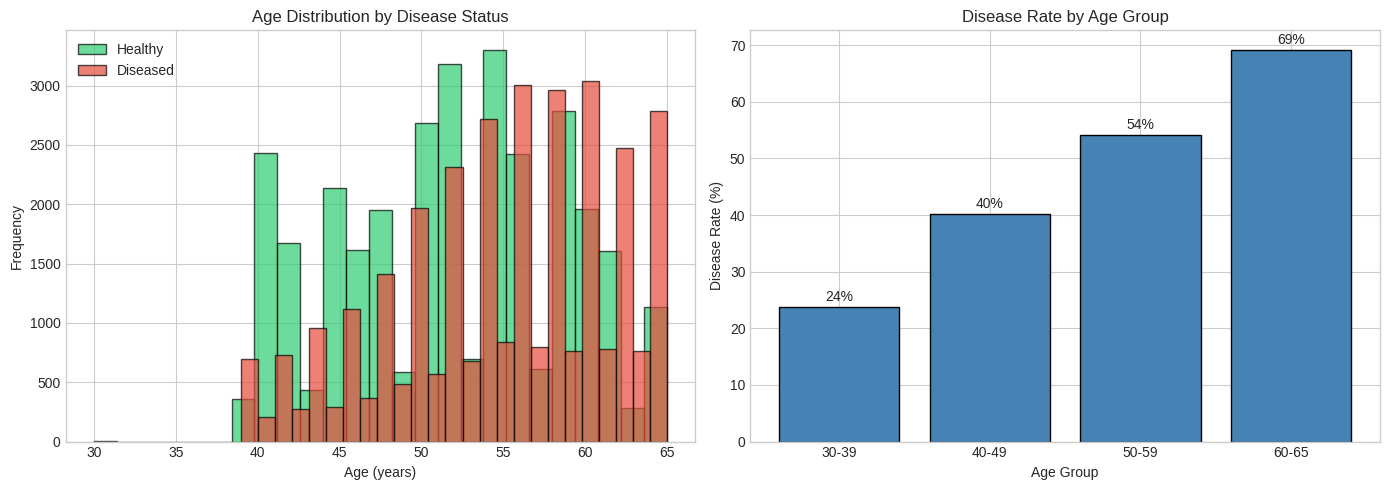

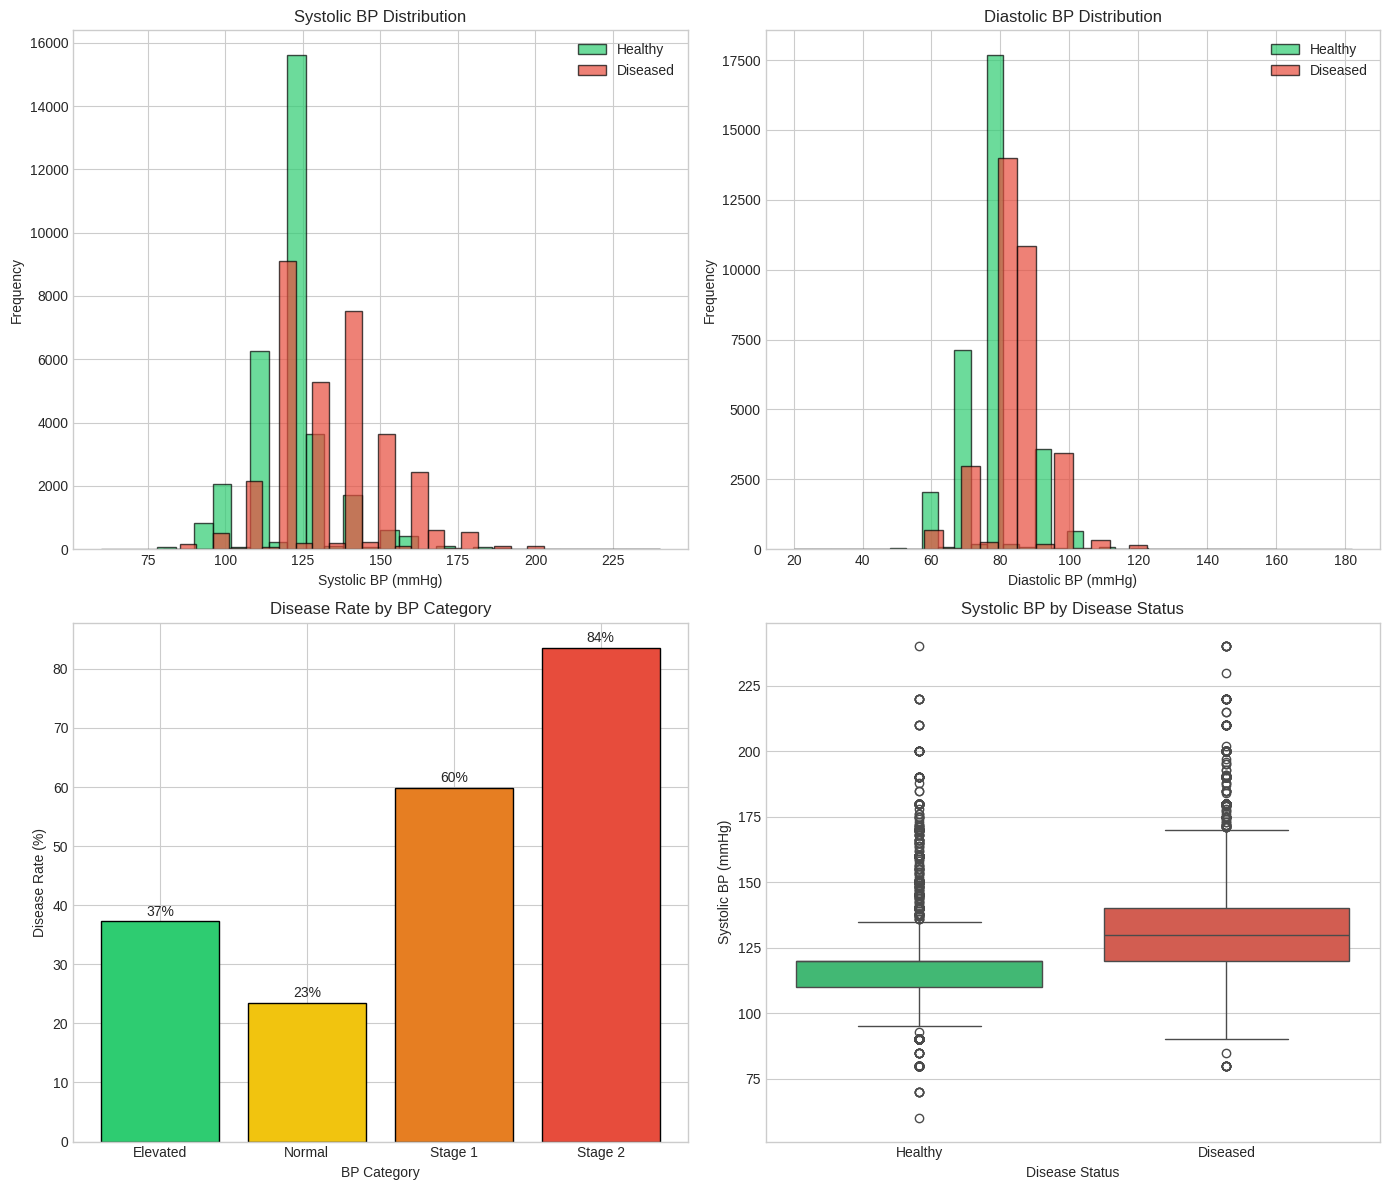

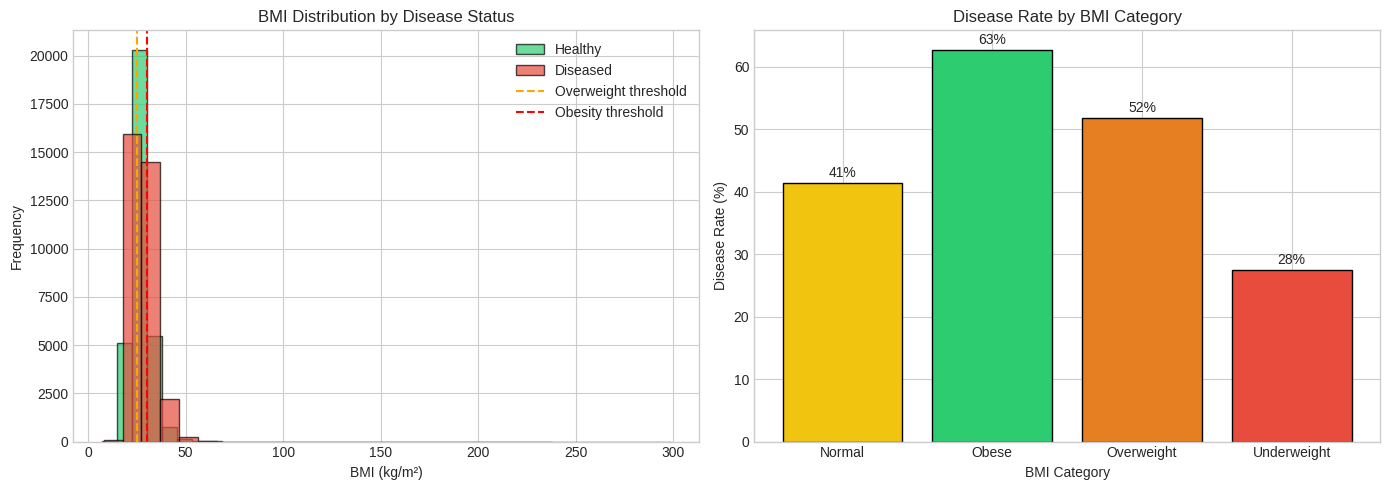

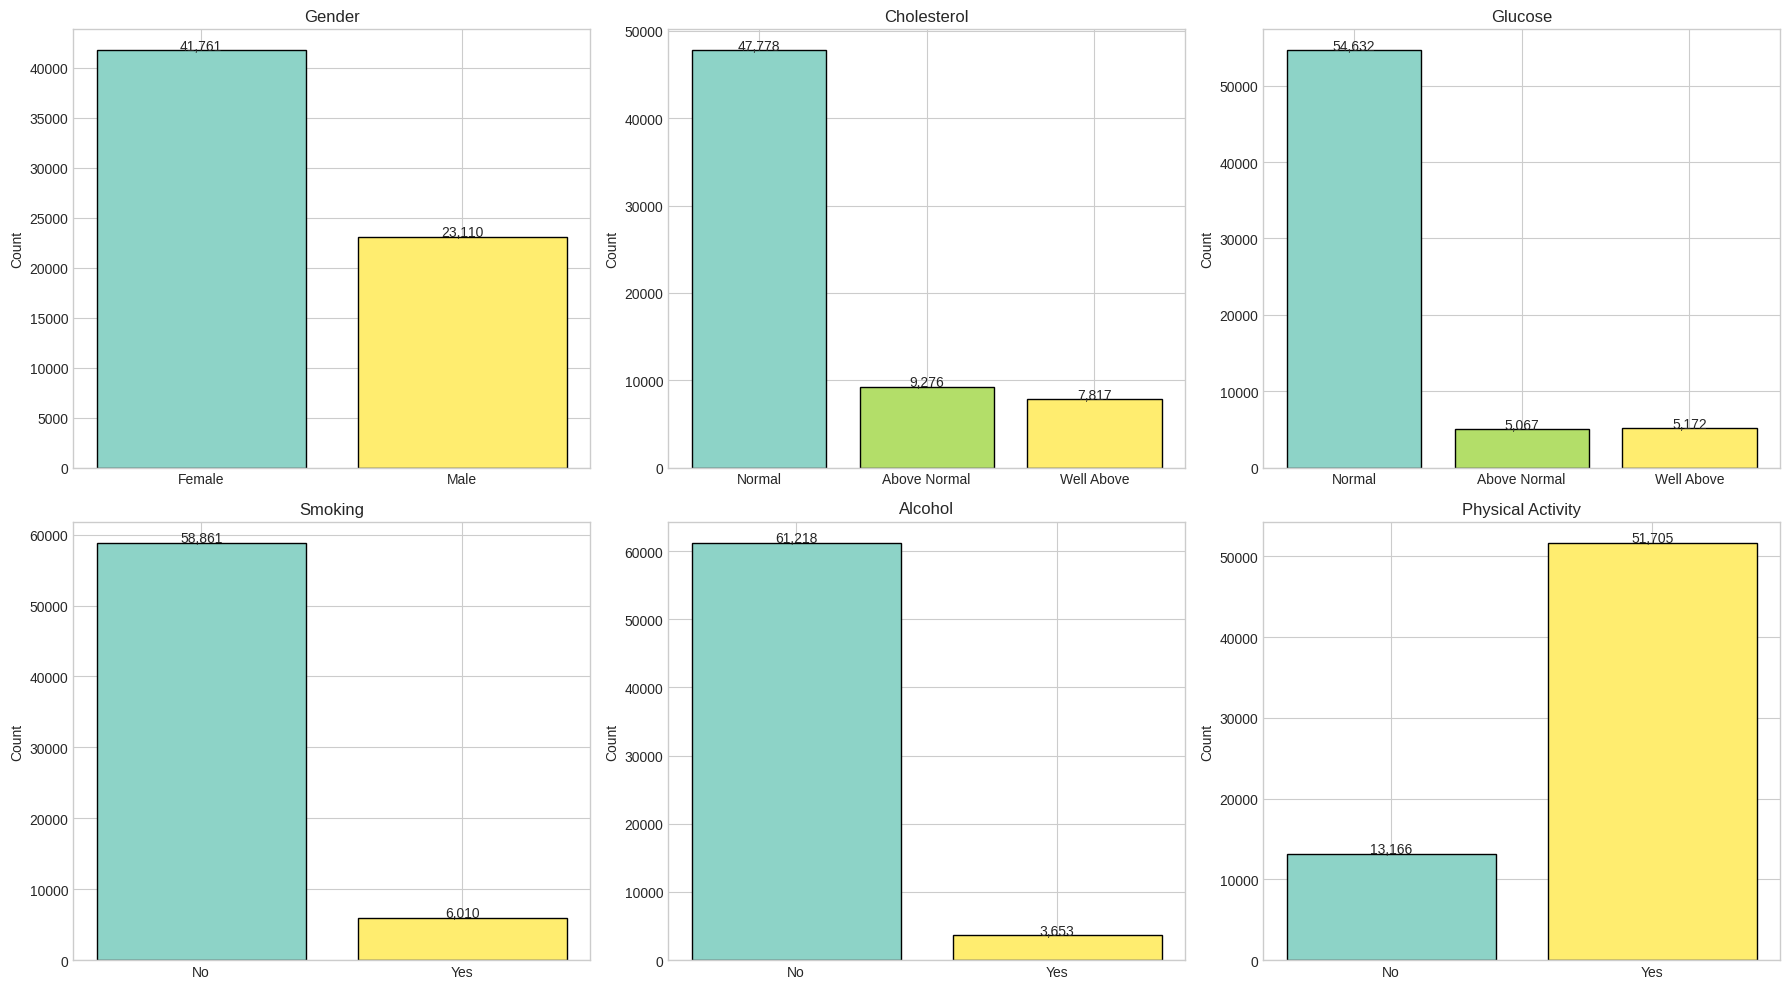

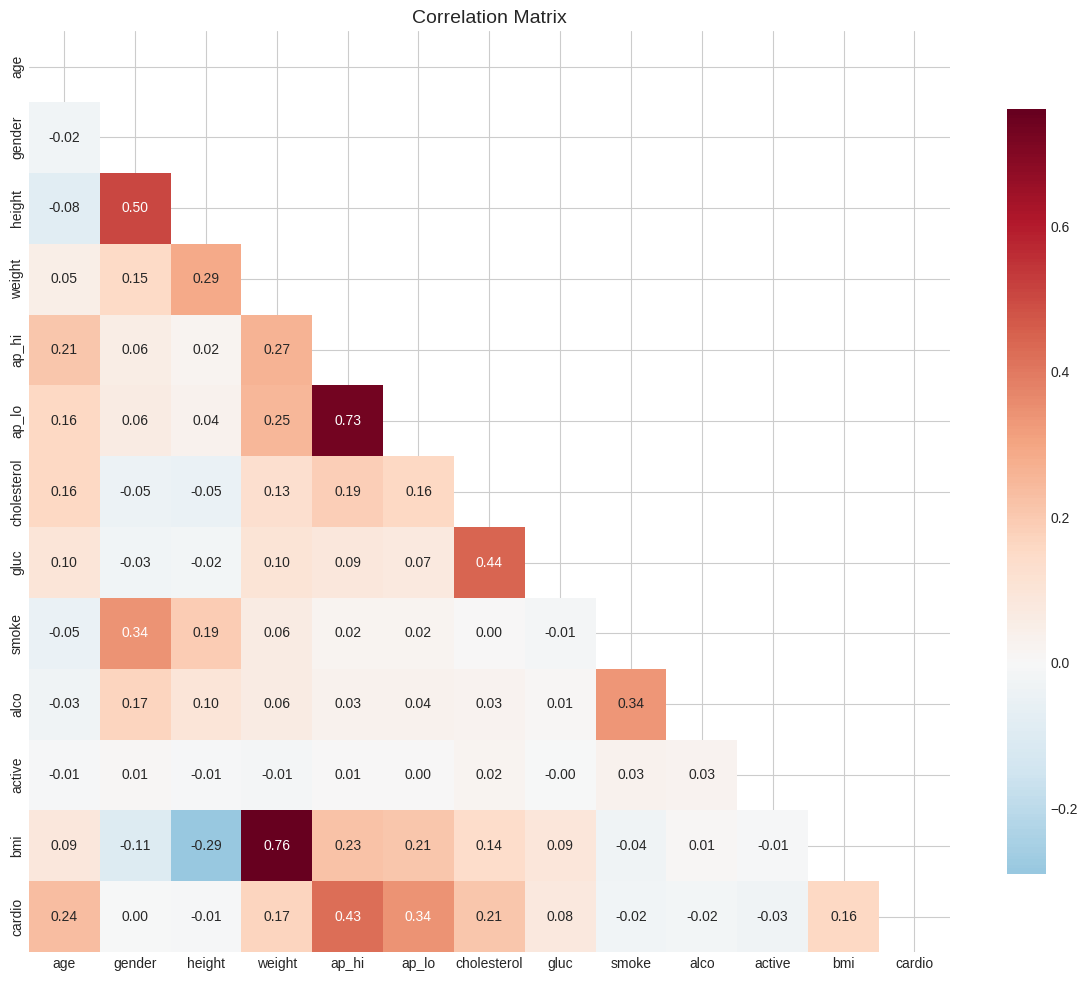

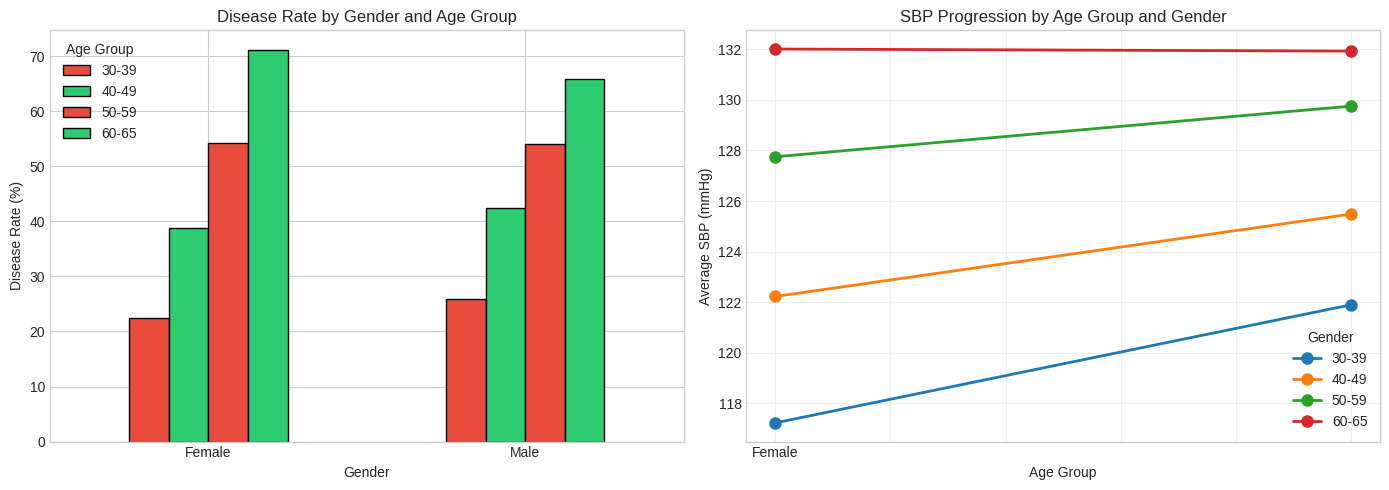

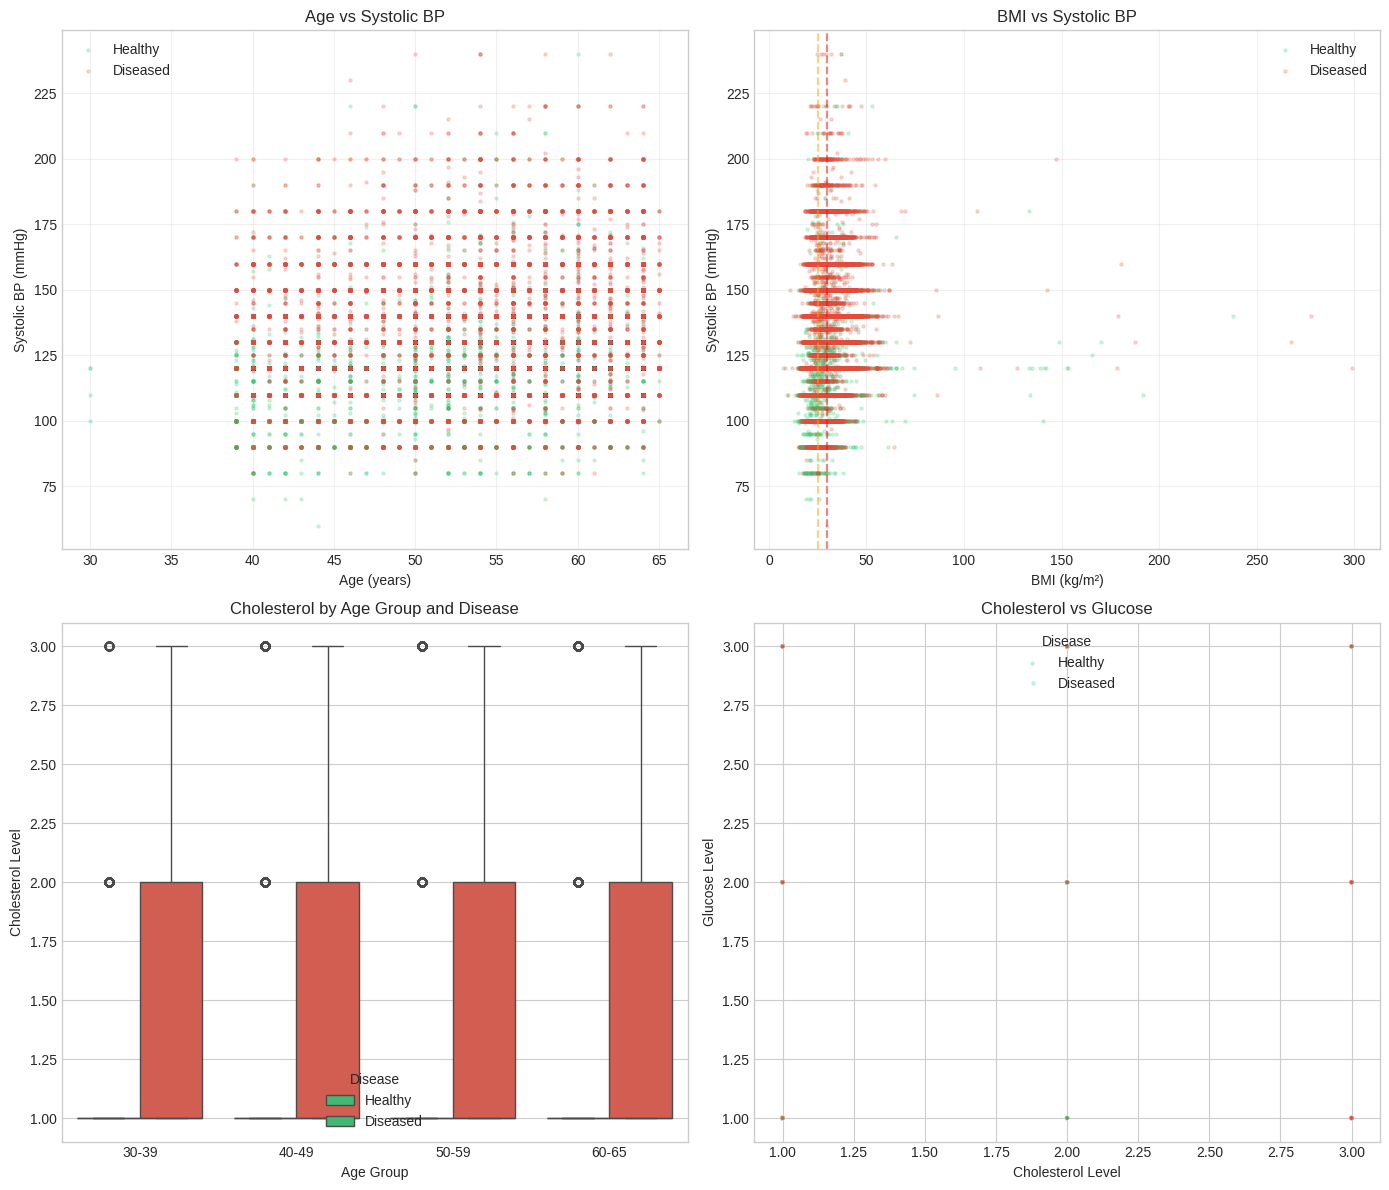

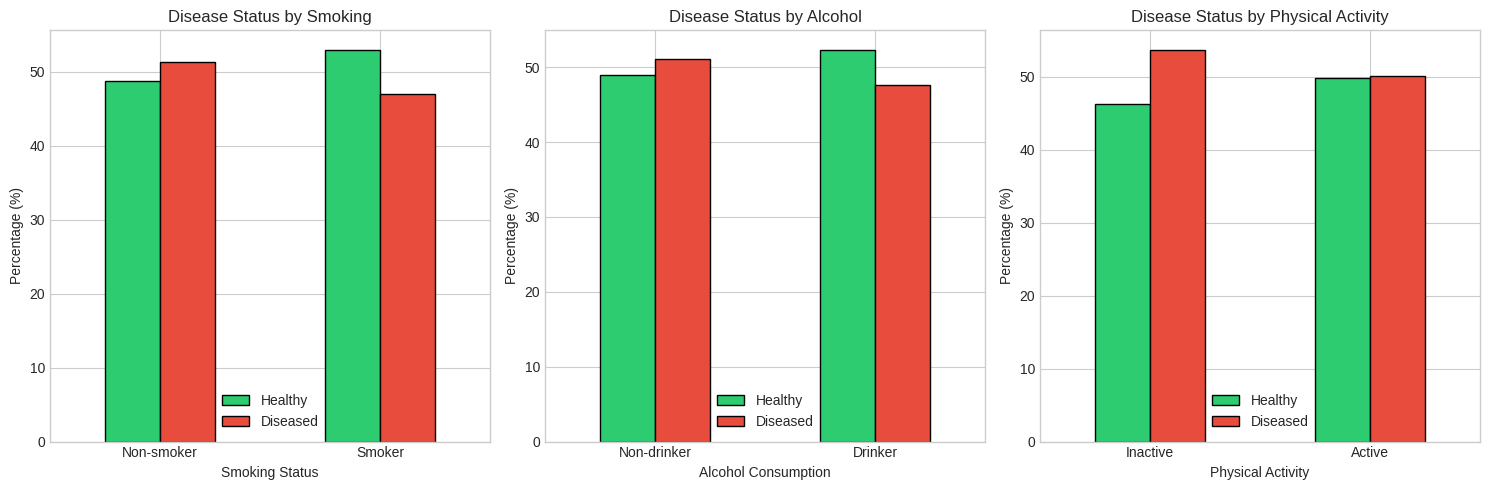


CLEANED DATA SAVED
File: /content/cardio_train_cleaned.csv
Shape: 64,871 rows, 19 columns
ANALYSIS COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================================
# CARDIOVASCULAR DISEASE DATASET - COMPLETE ANALYSIS PIPELINE
# EXPANDED FILTERING RANGES
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import SelectKBest, mutual_info_classif, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CLASS: DataLoader
# ============================================================================

class DataLoader:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

    def load_data(self):
        self.df = pd.read_csv(self.file_path, sep=';')
        return self.df

    def get_info(self):
        print("=" * 70)
        print("DATASET INFORMATION")
        print("=" * 70)
        print(f"Shape: {self.df.shape[0]:,} rows, {self.df.shape[1]} columns")
        print("\nColumns and data types:")
        print(self.df.dtypes)
        print("\nFirst 5 rows:")
        print(self.df.head())
        print("\nMissing values:")
        print(self.df.isnull().sum())
        print("\nBasic statistics:")
        print(self.df.describe())
        print("\nTarget distribution:")
        print(self.df['cardio'].value_counts())
        print(self.df['cardio'].value_counts(normalize=True) * 100)

# ============================================================================
# CLASS: DataCleaner
# ============================================================================

class DataCleaner:
    def __init__(self, df):
        self.df = df.copy()
        self.original_shape = df.shape

    def remove_id(self):
        if 'id' in self.df.columns:
            self.df = self.df.drop('id', axis=1)
        return self

    def convert_age(self):
        self.df['age'] = (self.df['age'] / 365.25).round().astype(int)
        return self

    def filter_height(self):
        before = len(self.df)
        self.df = self.df[(self.df['height'] >= 50) & (self.df['height'] <= 250)]
        print(f"Height filtered: {before - len(self.df)} rows removed (kept: 50-250 cm)")
        return self

    def filter_weight(self):
        before = len(self.df)
        self.df = self.df[(self.df['weight'] >= 20) & (self.df['weight'] <= 250)]
        print(f"Weight filtered: {before - len(self.df)} rows removed (kept: 20-250 kg)")
        return self

    def filter_blood_pressure(self):
        before = len(self.df)
        # Systolic must be greater than diastolic
        self.df = self.df[self.df['ap_hi'] > self.df['ap_lo']]
        # Systolic range: 30-300 mmHg
        self.df = self.df[(self.df['ap_hi'] >= 30) & (self.df['ap_hi'] <= 300)]
        # Diastolic range: 20-200 mmHg
        self.df = self.df[(self.df['ap_lo'] >= 20) & (self.df['ap_lo'] <= 200)]
        print(f"Blood pressure filtered: {before - len(self.df)} rows removed (sys:30-300, dia:20-200, sys>dia)")
        return self

    def validate_categorical(self):
        for col in ['cholesterol', 'gluc']:
            self.df = self.df[self.df[col].isin([1, 2, 3])]
        for col in ['smoke', 'alco', 'active']:
            self.df = self.df[self.df[col].isin([0, 1])]
        return self

    def remove_duplicates(self):
        before = len(self.df)
        self.df = self.df.drop_duplicates()
        print(f"Duplicates removed: {before - len(self.df)} rows")
        return self

    def reset_index(self):
        self.df = self.df.reset_index(drop=True)
        return self

    def get_cleaned_data(self):
        print(f"\nCleaning Summary:")
        print(f"Original: {self.original_shape[0]:,} rows")
        print(f"Cleaned: {self.df.shape[0]:,} rows")
        print(f"Removed: {self.original_shape[0] - self.df.shape[0]:,} rows")
        return self.df

# ============================================================================
# CLASS: FeatureEngineer
# ============================================================================

class FeatureEngineer:
    def __init__(self, df):
        self.df = df.copy()

    def add_bmi(self):
        self.df['bmi'] = self.df['weight'] / ((self.df['height'] / 100) ** 2)
        return self



    def add_gender_label(self):
        self.df['gender_label'] = self.df['gender'].map({1: 'Female', 2: 'Male'})
        return self

    def get_engineered_data(self):
        return self.df

# ============================================================================
# CLASS: DataAnalyzer
# ============================================================================

class DataAnalyzer:
    def __init__(self, df):
        self.df = df
        self.healthy = df[df['cardio'] == 0]
        self.diseased = df[df['cardio'] == 1]

    def target_distribution(self):
        print("\n" + "=" * 70)
        print("TARGET DISTRIBUTION")
        print("=" * 70)
        counts = self.df['cardio'].value_counts()
        pcts = self.df['cardio'].value_counts(normalize=True) * 100
        print(f"Healthy (0): {counts[0]:,} ({pcts[0]:.2f}%)")
        print(f"Diseased (1): {counts[1]:,} ({pcts[1]:.2f}%)")
        return counts, pcts

    def numerical_stats(self):
        print("\n" + "=" * 70)
        print("NUMERICAL FEATURES STATISTICS")
        print("=" * 70)
        numeric_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
        print(self.df[numeric_cols].describe())

    def categorical_stats(self):
        print("\n" + "=" * 70)
        print("CATEGORICAL FEATURES DISTRIBUTION")
        print("=" * 70)
        cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
        for col in cat_cols:
            print(f"\n{col}:")
            print(self.df[col].value_counts())
            print(self.df[col].value_counts(normalize=True) * 100)

    def disease_rates(self):
        print("\n" + "=" * 70)
        print("DISEASE RATES BY CATEGORY")
        print("=" * 70)

        print("\nBy Age Group:")
        age_rates = self.df.groupby('age_group')['cardio'].mean() * 100
        for k, v in age_rates.items():
            print(f"  {k}: {v:.1f}%")

        print("\nBy Gender:")
        gender_rates = self.df.groupby('gender_label')['cardio'].mean() * 100
        for k, v in gender_rates.items():
            print(f"  {k}: {v:.1f}%")

        print("\nBy BMI Category:")
        bmi_rates = self.df.groupby('bmi_category')['cardio'].mean() * 100
        for k, v in bmi_rates.items():
            print(f"  {k}: {v:.1f}%")

        print("\nBy BP Category:")
        bp_rates = self.df.groupby('bp_category')['cardio'].mean() * 100
        for k, v in bp_rates.items():
            print(f"  {k}: {v:.1f}%")

        print("\nBy Cholesterol Level:")
        chol_rates = self.df.groupby('cholesterol')['cardio'].mean() * 100
        chol_labels = {1: 'Normal', 2: 'Above Normal', 3: 'Well Above'}
        for k, v in chol_rates.items():
            print(f"  {chol_labels[k]}: {v:.1f}%")

        print("\nBy Smoking Status:")
        smoke_rates = self.df.groupby('smoke')['cardio'].mean() * 100
        print(f"  Non-smoker: {smoke_rates[0]:.1f}%")
        print(f"  Smoker: {smoke_rates[1]:.1f}%")

        print("\nBy Alcohol Consumption:")
        alco_rates = self.df.groupby('alco')['cardio'].mean() * 100
        print(f"  Non-drinker: {alco_rates[0]:.1f}%")
        print(f"  Drinker: {alco_rates[1]:.1f}%")

        print("\nBy Physical Activity:")
        active_rates = self.df.groupby('active')['cardio'].mean() * 100
        print(f"  Inactive: {active_rates[0]:.1f}%")
        print(f"  Active: {active_rates[1]:.1f}%")

    def correlation_analysis(self):
        print("\n" + "=" * 70)
        print("CORRELATION ANALYSIS")
        print("=" * 70)

        feature_cols = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                        'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']

        corr_with_target = self.df[feature_cols].corrwith(self.df['cardio']).sort_values(ascending=False)
        print("\nCorrelation with Target (cardio):")
        for feat, corr in corr_with_target.items():
            strength = "Strong" if abs(corr) > 0.3 else "Moderate" if abs(corr) > 0.2 else "Weak"
            print(f"  {feat}: {corr:+.4f} ({strength})")

        print("\nTop 5 Feature Correlations:")
        corr_matrix = self.df[feature_cols].corr()
        pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], abs(corr_matrix.iloc[i, j])))
        pairs.sort(key=lambda x: x[2], reverse=True)
        for f1, f2, r in pairs[:5]:
            print(f"  {f1} ↔ {f2}: {r:.3f}")

        return corr_with_target

    def gender_age_interaction(self):
        print("\n" + "=" * 70)
        print("GENDER AND AGE INTERACTION")
        print("=" * 70)

        age_gender = self.df.groupby(['gender_label', 'age_group'])['cardio'].mean().unstack() * 100
        print("\nDisease Rate by Age Group and Gender (%):")
        print(age_gender.round(1))

        print("\nAverage SBP by Age Group and Gender:")
        bp_age_gender = self.df.groupby(['gender_label', 'age_group'])['ap_hi'].mean().unstack().round(1)
        print(bp_age_gender)

    def bmi_bp_interaction(self):
        print("\n" + "=" * 70)
        print("BMI AND BLOOD PRESSURE INTERACTION")
        print("=" * 70)

        bmi_bp = self.df.groupby('bmi_category')['ap_hi'].mean().round(1)
        print("\nAverage SBP by BMI Category:")
        for k, v in bmi_bp.items():
            print(f"  {k}: {v:.1f} mmHg")

        bmi_hyper = self.df.groupby('bmi_category').apply(
            lambda x: (x['ap_hi'] >= 140).mean() * 100
        ).round(1)
        print("\nHypertension Rate by BMI Category (%):")
        for k, v in bmi_hyper.items():
            print(f"  {k}: {v:.1f}%")

    def cholesterol_gluc_interaction(self):
        print("\n" + "=" * 70)
        print("CHOLESTEROL AND GLUCOSE INTERACTION")
        print("=" * 70)

        chol_gluc_disease = self.df.groupby(['cholesterol', 'gluc'])['cardio'].mean().unstack() * 100
        print("\nDisease Rate by Cholesterol and Glucose (%):")
        print(chol_gluc_disease.round(1))

        chol_gluc_count = self.df.groupby(['cholesterol', 'gluc']).size().unstack()
        print("\nPatient Count by Cholesterol and Glucose:")
        print(chol_gluc_count)

    def statistical_tests(self):
        print("\n" + "=" * 70)
        print("STATISTICAL TESTS (Healthy vs Diseased)")
        print("=" * 70)

        features = ['age', 'bmi', 'ap_hi', 'ap_lo', 'cholesterol']
        for feature in features:
            t_stat, p_value = stats.ttest_ind(self.healthy[feature], self.diseased[feature])
            result = "Significant" if p_value < 0.001 else "Not significant"
            print(f"  {feature}: t={t_stat:.2f}, p={p_value:.4f} ({result})")

    def outlier_analysis(self):
        print("\n" + "=" * 70)
        print("OUTLIER ANALYSIS (IQR Method)")
        print("=" * 70)

        numeric_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
        for col in numeric_cols:
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            outliers = self.df[(self.df[col] < lower) | (self.df[col] > upper)].shape[0]
            print(f"  {col}: {outliers} outliers ({outliers/len(self.df)*100:.2f}%)")

# ============================================================================
# CLASS: Visualizer
# ============================================================================

class Visualizer:
    def __init__(self, df):
        self.df = df
        self.healthy = df[df['cardio'] == 0]
        self.diseased = df[df['cardio'] == 1]
        plt.style.use('seaborn-v0_8-whitegrid')

    def plot_target_distribution(self):
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        counts = self.df['cardio'].value_counts()
        axes[0].bar(['Healthy (0)', 'Diseased (1)'], counts.values,
                    color=['#2ecc71', '#e74c3c'], edgecolor='black')
        axes[0].set_title('Target Distribution')
        axes[0].set_ylabel('Count')
        for i, v in enumerate(counts.values):
            axes[0].text(i, v + 500, f'{v:,}', ha='center')

        self.df['cardio'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1],
                                                   colors=['#2ecc71', '#e74c3c'],
                                                   explode=(0.05, 0.05))
        axes[1].set_title('Target Distribution (%)')
        axes[1].set_ylabel('')

        plt.tight_layout()
        plt.savefig('/content/target_distribution.png', dpi=150)
        plt.show()

    def plot_age_distribution(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].hist(self.healthy['age'], bins=25, alpha=0.7, label='Healthy',
                     color='#2ecc71', edgecolor='black')
        axes[0].hist(self.diseased['age'], bins=25, alpha=0.7, label='Diseased',
                     color='#e74c3c', edgecolor='black')
        axes[0].set_xlabel('Age (years)')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('Age Distribution by Disease Status')
        axes[0].legend()

        age_rates = self.df.groupby('age_group')['cardio'].mean() * 100
        axes[1].bar(age_rates.index, age_rates.values, color='steelblue', edgecolor='black')
        axes[1].set_xlabel('Age Group')
        axes[1].set_ylabel('Disease Rate (%)')
        axes[1].set_title('Disease Rate by Age Group')
        for i, v in enumerate(age_rates.values):
            axes[1].text(i, v + 1, f'{v:.0f}%', ha='center')

        plt.tight_layout()
        plt.savefig('/content/age_analysis.png', dpi=150)
        plt.show()

    def plot_blood_pressure(self):
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))

        # Systolic BP distribution
        axes[0, 0].hist(self.healthy['ap_hi'], bins=30, alpha=0.7, label='Healthy',
                        color='#2ecc71', edgecolor='black')
        axes[0, 0].hist(self.diseased['ap_hi'], bins=30, alpha=0.7, label='Diseased',
                        color='#e74c3c', edgecolor='black')
        axes[0, 0].set_xlabel('Systolic BP (mmHg)')
        axes[0, 0].set_ylabel('Frequency')
        axes[0, 0].set_title('Systolic BP Distribution')
        axes[0, 0].legend()

        # Diastolic BP distribution
        axes[0, 1].hist(self.healthy['ap_lo'], bins=30, alpha=0.7, label='Healthy',
                        color='#2ecc71', edgecolor='black')
        axes[0, 1].hist(self.diseased['ap_lo'], bins=30, alpha=0.7, label='Diseased',
                        color='#e74c3c', edgecolor='black')
        axes[0, 1].set_xlabel('Diastolic BP (mmHg)')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].set_title('Diastolic BP Distribution')
        axes[0, 1].legend()

        # Disease rate by BP category
        bp_rates = self.df.groupby('bp_category')['cardio'].mean() * 100
        axes[1, 0].bar(bp_rates.index, bp_rates.values,
                       color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'],
                       edgecolor='black')
        axes[1, 0].set_xlabel('BP Category')
        axes[1, 0].set_ylabel('Disease Rate (%)')
        axes[1, 0].set_title('Disease Rate by BP Category')
        for i, v in enumerate(bp_rates.values):
            axes[1, 0].text(i, v + 1, f'{v:.0f}%', ha='center')

        # Boxplot
        sns.boxplot(data=self.df, x='cardio', y='ap_hi', ax=axes[1, 1],
                   palette=['#2ecc71', '#e74c3c'])
        axes[1, 1].set_xticklabels(['Healthy', 'Diseased'])
        axes[1, 1].set_xlabel('Disease Status')
        axes[1, 1].set_ylabel('Systolic BP (mmHg)')
        axes[1, 1].set_title('Systolic BP by Disease Status')

        plt.tight_layout()
        plt.savefig('/content/blood_pressure_analysis.png', dpi=150)
        plt.show()

    def plot_bmi_analysis(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].hist(self.healthy['bmi'], bins=30, alpha=0.7, label='Healthy',
                     color='#2ecc71', edgecolor='black')
        axes[0].hist(self.diseased['bmi'], bins=30, alpha=0.7, label='Diseased',
                     color='#e74c3c', edgecolor='black')
        axes[0].set_xlabel('BMI (kg/m²)')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('BMI Distribution by Disease Status')
        axes[0].axvline(x=25, color='orange', linestyle='--', label='Overweight threshold')
        axes[0].axvline(x=30, color='red', linestyle='--', label='Obesity threshold')
        axes[0].legend()

        bmi_rates = self.df.groupby('bmi_category')['cardio'].mean() * 100
        colors = ['#f1c40f', '#2ecc71', '#e67e22', '#e74c3c']
        axes[1].bar(bmi_rates.index, bmi_rates.values, color=colors, edgecolor='black')
        axes[1].set_xlabel('BMI Category')
        axes[1].set_ylabel('Disease Rate (%)')
        axes[1].set_title('Disease Rate by BMI Category')
        for i, v in enumerate(bmi_rates.values):
            axes[1].text(i, v + 1, f'{v:.0f}%', ha='center')

        plt.tight_layout()
        plt.savefig('/content/bmi_analysis.png', dpi=150)
        plt.show()

    def plot_categorical_features(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
        titles = ['Gender', 'Cholesterol', 'Glucose', 'Smoking', 'Alcohol', 'Physical Activity']

        for i, (col, title) in enumerate(zip(cat_cols, titles)):
            ax = axes[i // 3, i % 3]
            if col == 'gender':
                labels = ['Female', 'Male']
                values = self.df[col].value_counts().sort_index().values
            elif col in ['cholesterol', 'gluc']:
                labels = ['Normal', 'Above Normal', 'Well Above']
                values = self.df[col].value_counts().sort_index().values
            else:
                labels = ['No', 'Yes']
                values = self.df[col].value_counts().sort_index().values

            colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
            ax.bar(labels, values, color=colors, edgecolor='black')
            ax.set_title(title)
            ax.set_ylabel('Count')
            for j, v in enumerate(values):
                ax.text(j, v + 50, f'{v:,}', ha='center')

        plt.tight_layout()
        plt.savefig('/content/categorical_features.png', dpi=150)
        plt.show()

    def plot_correlation_heatmap(self):
        feature_cols = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                        'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'cardio']

        plt.figure(figsize=(12, 10))
        corr_matrix = self.df[feature_cols].corr()
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                   cmap='RdBu_r', center=0, square=True,
                   cbar_kws={"shrink": 0.8})
        plt.title('Correlation Matrix', fontsize=14)
        plt.tight_layout()
        plt.savefig('/content/correlation_heatmap.png', dpi=150)
        plt.show()

    def plot_gender_age_interaction(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        age_gender = self.df.groupby(['gender_label', 'age_group'])['cardio'].mean().unstack() * 100
        age_gender.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
        axes[0].set_xlabel('Gender')
        axes[0].set_ylabel('Disease Rate (%)')
        axes[0].set_title('Disease Rate by Gender and Age Group')
        axes[0].legend(title='Age Group')
        axes[0].tick_params(axis='x', rotation=0)

        bp_age_gender = self.df.groupby(['gender_label', 'age_group'])['ap_hi'].mean().unstack()
        bp_age_gender.plot(kind='line', marker='o', ax=axes[1], linewidth=2, markersize=8)
        axes[1].set_xlabel('Age Group')
        axes[1].set_ylabel('Average SBP (mmHg)')
        axes[1].set_title('SBP Progression by Age Group and Gender')
        axes[1].legend(title='Gender')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/gender_age_interaction.png', dpi=150)
        plt.show()

    def plot_scatter_relationships(self):
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))

        # Age vs SBP
        for disease, color, label in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Healthy', 'Diseased']):
            subset = self.df[self.df['cardio'] == disease]
            axes[0, 0].scatter(subset['age'], subset['ap_hi'], alpha=0.2, s=5, c=color, label=label)
        axes[0, 0].set_xlabel('Age (years)')
        axes[0, 0].set_ylabel('Systolic BP (mmHg)')
        axes[0, 0].set_title('Age vs Systolic BP')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # BMI vs SBP
        for disease, color, label in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Healthy', 'Diseased']):
            subset = self.df[self.df['cardio'] == disease]
            axes[0, 1].scatter(subset['bmi'], subset['ap_hi'], alpha=0.2, s=5, c=color, label=label)
        axes[0, 1].set_xlabel('BMI (kg/m²)')
        axes[0, 1].set_ylabel('Systolic BP (mmHg)')
        axes[0, 1].set_title('BMI vs Systolic BP')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].axvline(x=25, color='orange', linestyle='--', alpha=0.5)
        axes[0, 1].axvline(x=30, color='red', linestyle='--', alpha=0.5)

        # Cholesterol vs Age
        sns.boxplot(data=self.df, x='age_group', y='cholesterol', hue='cardio', ax=axes[1, 0],
                   palette=['#2ecc71', '#e74c3c'])
        axes[1, 0].set_xlabel('Age Group')
        axes[1, 0].set_ylabel('Cholesterol Level')
        axes[1, 0].set_title('Cholesterol by Age Group and Disease')
        axes[1, 0].legend(title='Disease', labels=['Healthy', 'Diseased'])

        # Glucose vs Cholesterol
        sns.scatterplot(data=self.df, x='cholesterol', y='gluc', hue='cardio', ax=axes[1, 1],
                       palette=['#2ecc71', '#e74c3c'], alpha=0.3, s=10)
        axes[1, 1].set_xlabel('Cholesterol Level')
        axes[1, 1].set_ylabel('Glucose Level')
        axes[1, 1].set_title('Cholesterol vs Glucose')
        axes[1, 1].legend(title='Disease', labels=['Healthy', 'Diseased'])

        plt.tight_layout()
        plt.savefig('/content/scatter_relationships.png', dpi=150)
        plt.show()

    def plot_lifestyle_factors(self):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Smoking
        smoke_disease = self.df.groupby(['smoke', 'cardio']).size().unstack()
        smoke_disease_pct = smoke_disease.div(smoke_disease.sum(axis=1), axis=0) * 100
        smoke_disease_pct.columns = ['Healthy', 'Diseased']
        smoke_disease_pct.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
        axes[0].set_xlabel('Smoking Status')
        axes[0].set_ylabel('Percentage (%)')
        axes[0].set_title('Disease Status by Smoking')
        axes[0].set_xticklabels(['Non-smoker', 'Smoker'], rotation=0)
        axes[0].legend()

        # Alcohol
        alco_disease = self.df.groupby(['alco', 'cardio']).size().unstack()
        alco_disease_pct = alco_disease.div(alco_disease.sum(axis=1), axis=0) * 100
        alco_disease_pct.columns = ['Healthy', 'Diseased']
        alco_disease_pct.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
        axes[1].set_xlabel('Alcohol Consumption')
        axes[1].set_ylabel('Percentage (%)')
        axes[1].set_title('Disease Status by Alcohol')
        axes[1].set_xticklabels(['Non-drinker', 'Drinker'], rotation=0)
        axes[1].legend()

        # Physical Activity
        active_disease = self.df.groupby(['active', 'cardio']).size().unstack()
        active_disease_pct = active_disease.div(active_disease.sum(axis=1), axis=0) * 100
        active_disease_pct.columns = ['Healthy', 'Diseased']
        active_disease_pct.plot(kind='bar', ax=axes[2], color=['#2ecc71', '#e74c3c'], edgecolor='black')
        axes[2].set_xlabel('Physical Activity')
        axes[2].set_ylabel('Percentage (%)')
        axes[2].set_title('Disease Status by Physical Activity')
        axes[2].set_xticklabels(['Inactive', 'Active'], rotation=0)
        axes[2].legend()

        plt.tight_layout()
        plt.savefig('/content/lifestyle_factors.png', dpi=150)
        plt.show()

    def plot_all_visualizations(self):
        self.plot_target_distribution()
        self.plot_age_distribution()
        self.plot_blood_pressure()
        self.plot_bmi_analysis()
        self.plot_categorical_features()
        self.plot_correlation_heatmap()
        self.plot_gender_age_interaction()
        self.plot_scatter_relationships()
        self.plot_lifestyle_factors()

# ============================================================================
# CLASS: FeatureSelector
# ============================================================================

class FeatureSelector:
    def __init__(self, df):
        self.df = df
        self.feature_cols = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                            'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
        self.X = df[self.feature_cols]
        self.y = df['cardio']

    def mutual_information(self):
        print("\n" + "=" * 70)
        print("FEATURE SELECTION: MUTUAL INFORMATION")
        print("=" * 70)

        mi = mutual_info_classif(self.X, self.y)
        results = pd.DataFrame({'Feature': self.feature_cols, 'MI_Score': mi})
        results = results.sort_values('MI_Score', ascending=False)
        print(results)
        return results

    def f_statistic(self):
        print("\n" + "=" * 70)
        print("FEATURE SELECTION: F-STATISTIC")
        print("=" * 70)

        f_test = f_classif(self.X, self.y)
        results = pd.DataFrame({'Feature': self.feature_cols, 'F_Score': f_test[0]})
        results = results.sort_values('F_Score', ascending=False)
        print(results)
        return results

    def random_forest_importance(self):
        print("\n" + "=" * 70)
        print("FEATURE SELECTION: RANDOM FOREST IMPORTANCE")
        print("=" * 70)

        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(self.X, self.y)
        results = pd.DataFrame({'Feature': self.feature_cols, 'Importance': rf.feature_importances_})
        results = results.sort_values('Importance', ascending=False)
        print(results)
        return results

    def lasso_selection(self):
        print("\n" + "=" * 70)
        print("FEATURE SELECTION: LASSO (L1 Regularization)")
        print("=" * 70)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(self.X)

        lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
        lasso.fit(X_scaled, self.y)

        results = pd.DataFrame({
            'Feature': self.feature_cols,
            'Coefficient': lasso.coef_,
            'Selected': np.abs(lasso.coef_) > 0
        })
        results = results.sort_values('Coefficient', ascending=False)
        print(results)
        return results

    def rfe_selection(self, n_features=6):
        print("\n" + "=" * 70)
        print(f"FEATURE SELECTION: RFE (Top {n_features} Features)")
        print("=" * 70)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(self.X)

        estimator = RandomForestClassifier(n_estimators=100, random_state=42)
        rfe = RFE(estimator, n_features_to_select=n_features)
        rfe.fit(X_scaled, self.y)

        results = pd.DataFrame({
            'Feature': self.feature_cols,
            'Selected': rfe.support_,
            'Ranking': rfe.ranking_
        })
        results = results.sort_values('Ranking')
        print(results)
        return results

    def consensus_ranking(self):
        print("\n" + "=" * 70)
        print("FEATURE SELECTION: CONSENSUS RANKING")
        print("=" * 70)

        mi = mutual_info_classif(self.X, self.y)
        f_test = f_classif(self.X, self.y)
        rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(self.X, self.y)

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(self.X)
        lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
        lasso.fit(X_scaled, self.y)

        results = pd.DataFrame({'Feature': self.feature_cols})
        results['MI_Rank'] = mi.argsort()[::-1].argsort() + 1
        results['F_Rank'] = f_test[0].argsort()[::-1].argsort() + 1
        results['RF_Rank'] = rf.feature_importances_.argsort()[::-1].argsort() + 1
        results['Lasso_Selected'] = np.abs(lasso.coef_) > 0

        results['Avg_Rank'] = results[['MI_Rank', 'F_Rank', 'RF_Rank']].mean(axis=1)
        results = results.sort_values('Avg_Rank')
        results['Final_Rank'] = range(1, len(results) + 1)

        print(results[['Feature', 'MI_Rank', 'F_Rank', 'RF_Rank', 'Avg_Rank', 'Final_Rank', 'Lasso_Selected']])
        return results

# ============================================================================
# MAIN EXECUTION PIPELINE
# ============================================================================

print("=" * 70)
print("CARDIOVASCULAR DISEASE DATASET - COMPLETE ANALYSIS")
print("=" * 70)

# Load Data
loader = DataLoader('/content/cardio_train.csv')
df = loader.load_data()
loader.get_info()

# Clean Data (EXPANDED FILTERING RANGES)
cleaner = DataCleaner(df)
df_cleaned = (cleaner
              .remove_id()
              .convert_age()
              .filter_height()       # 50-250 cm
              .filter_weight()       # 20-250 kg
              .filter_blood_pressure()  # sys:30-300, dia:20-200, sys>dia
              .validate_categorical()
              .remove_duplicates()
              .reset_index()
              .get_cleaned_data())

# Feature Engineering
engineer = FeatureEngineer(df_cleaned)
df_engineered = (engineer
                 .add_bmi()
                 .get_engineered_data())

# Analysis
analyzer = DataAnalyzer(df_engineered)
analyzer.target_distribution()
analyzer.numerical_stats()
analyzer.categorical_stats()
analyzer.disease_rates()
analyzer.correlation_analysis()
analyzer.gender_age_interaction()
analyzer.bmi_bp_interaction()
analyzer.cholesterol_gluc_interaction()
analyzer.statistical_tests()
analyzer.outlier_analysis()

# Feature Selection
selector = FeatureSelector(df_engineered)
selector.mutual_information()
selector.f_statistic()
selector.random_forest_importance()
selector.lasso_selection()
selector.rfe_selection(n_features=6)
selector.consensus_ranking()

# Visualization
visualizer = Visualizer(df_engineered)
visualizer.plot_all_visualizations()

# Save cleaned data
df_engineered.to_csv('/content/cardio_train_cleaned.csv', index=False)
print("\n" + "=" * 70)
print("CLEANED DATA SAVED")
print("=" * 70)
print(f"File: /content/cardio_train_cleaned.csv")
print(f"Shape: {df_engineered.shape[0]:,} rows, {df_engineered.shape[1]} columns")
print("=" * 70)
print("ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 70)

STRATIFIED ANALYSIS

STRATIFIED ANALYSIS: GENDER AND AGE SEGMENTATION

DISEASE DISTRIBUTION BY GENDER

Overall Disease Rate:
  Female: 50.9%
  Male: 50.9%
  Difference: 0.0%

Disease Rate by Age Group and Gender:
age_group     30-39  40-49  50-59  60-65
gender_label                            
Female         22.5   38.8   54.2   71.1
Male           25.9   42.4   54.1   65.9

DISEASE DISTRIBUTION BY AGE SEGMENTS

Young (30-44):
  Total: 9,431 patients, Disease Rate: 30.3%
  Female: 29.0%, Male: 32.6%

Middle (45-54):
  Total: 25,713 patients, Disease Rate: 46.4%
  Female: 45.6%, Male: 47.8%

Older (55-65):
  Total: 29,686 patients, Disease Rate: 61.3%
  Female: 61.9%, Male: 60.2%

RISK FACTORS BY GENDER

Average Values by Gender:
------------------------------------------------------------
  age         : Female=53.44, Male=53.09, Diff=-0.34
  ap_hi       : Female=126.32, Male=128.36, Diff=+2.04
  ap_lo       : Female=80.93, Male=82.25, Diff=+1.32
  bmi         : Female=28.10, Male=26.76, Diff=-1.34
  chole

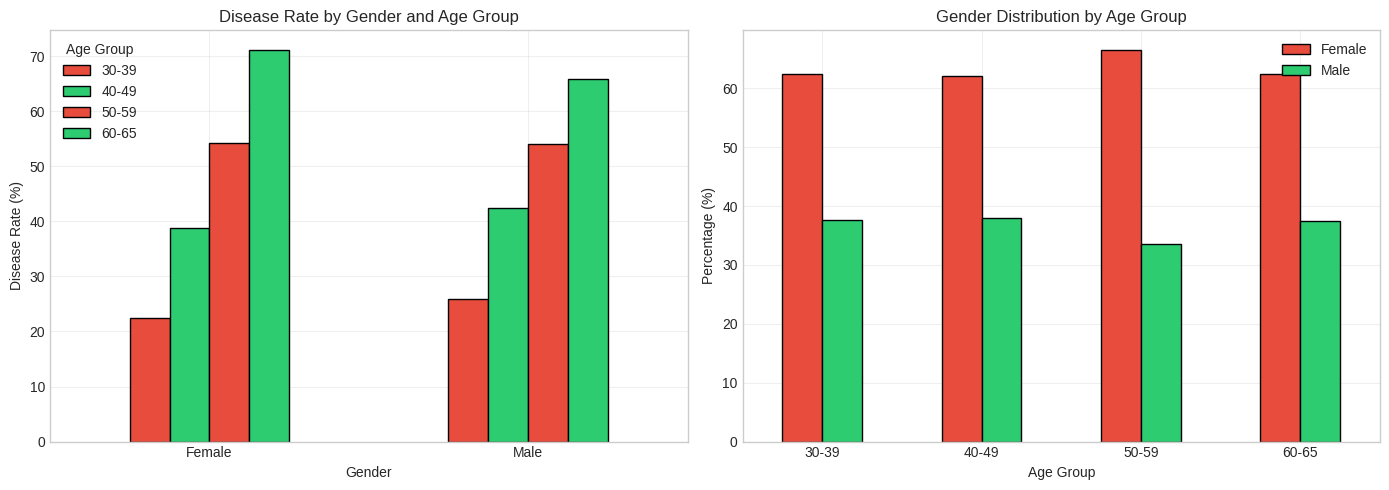

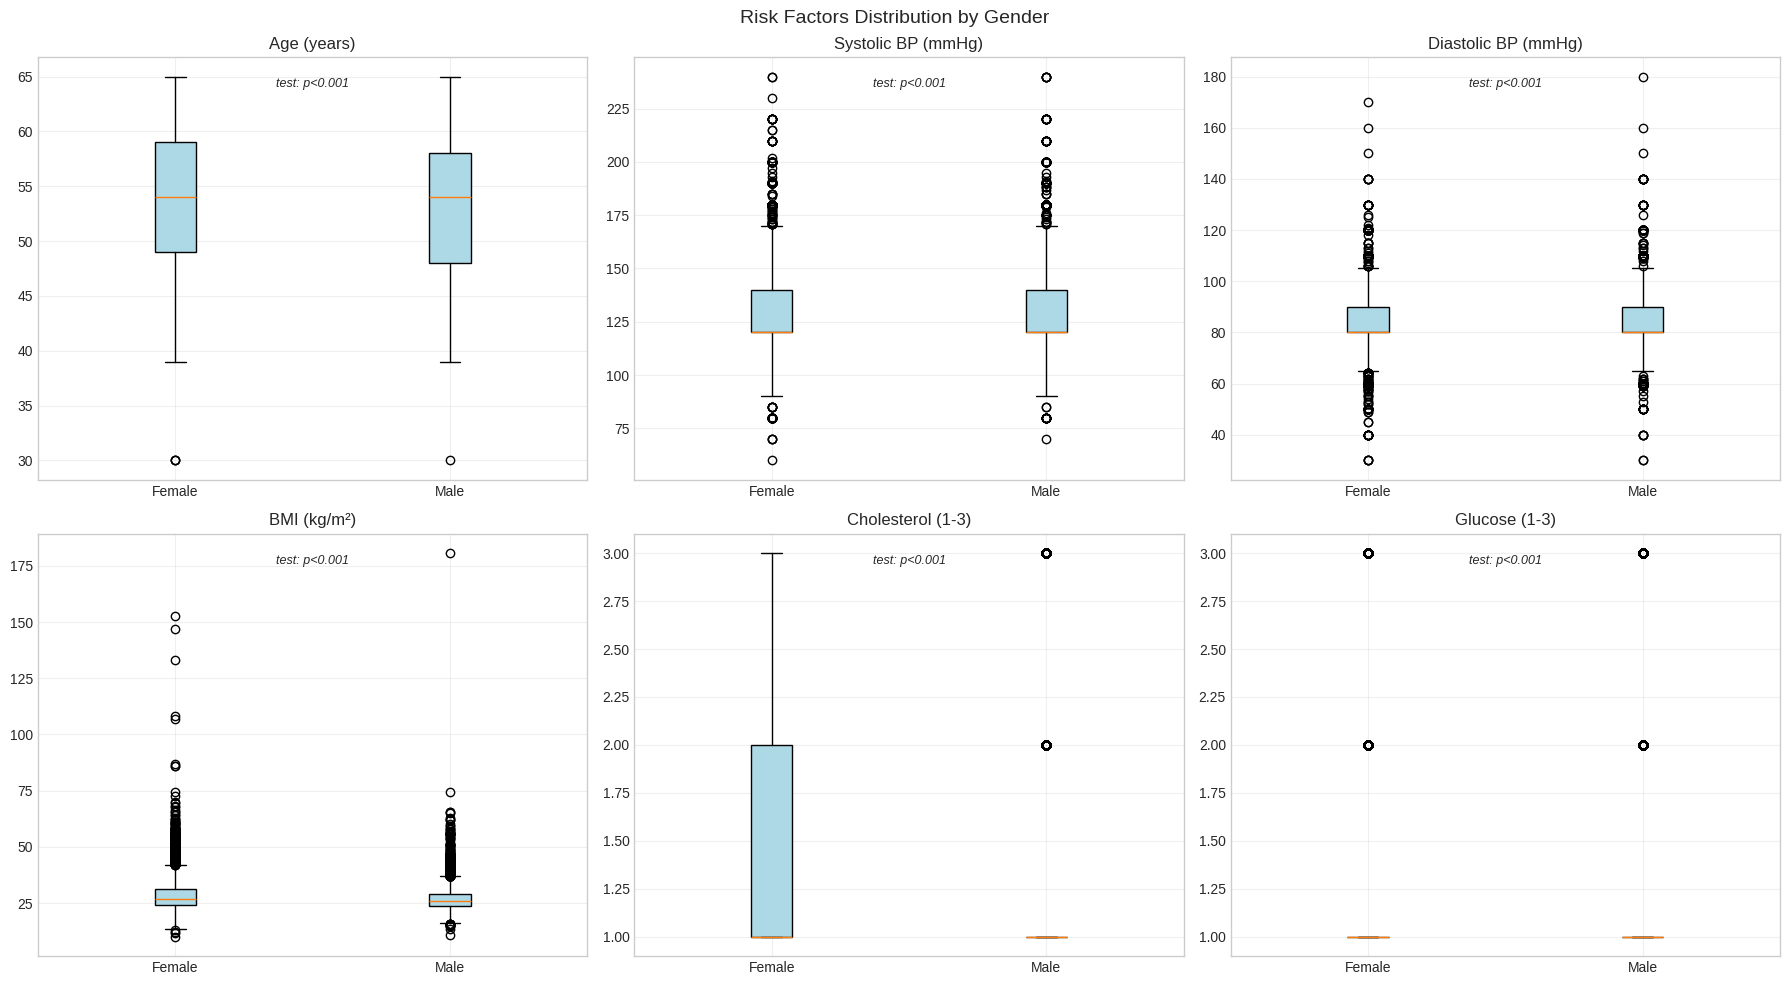

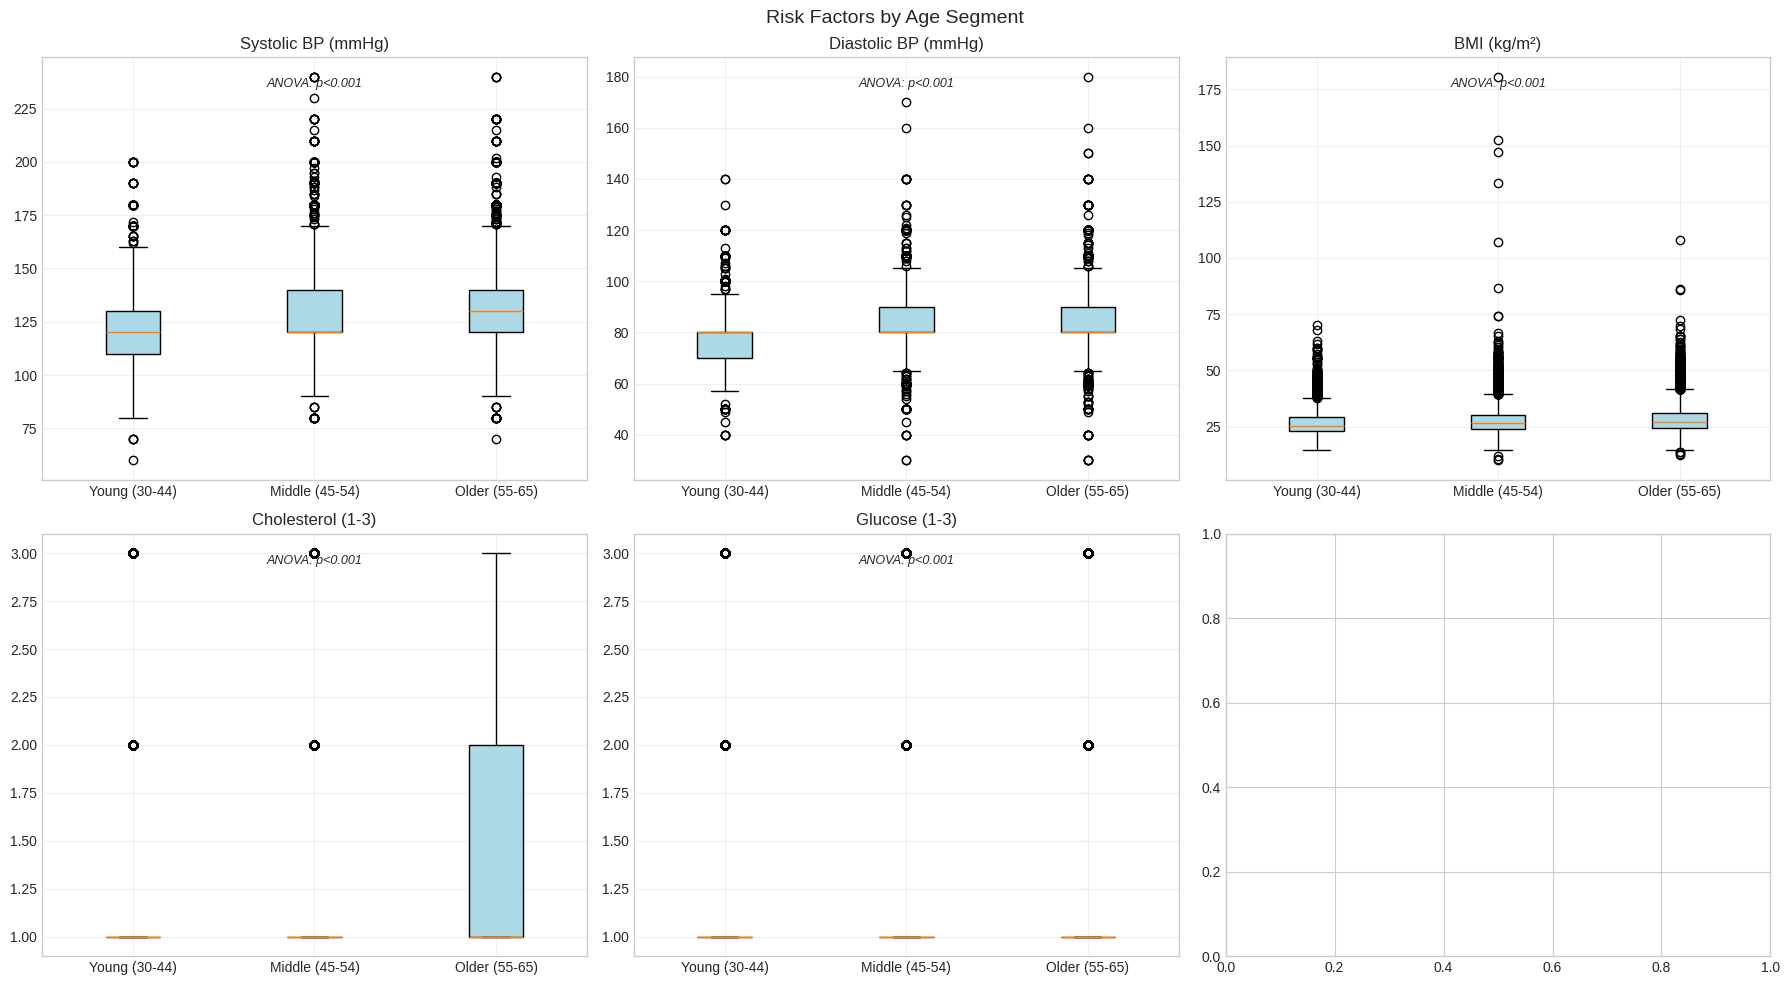

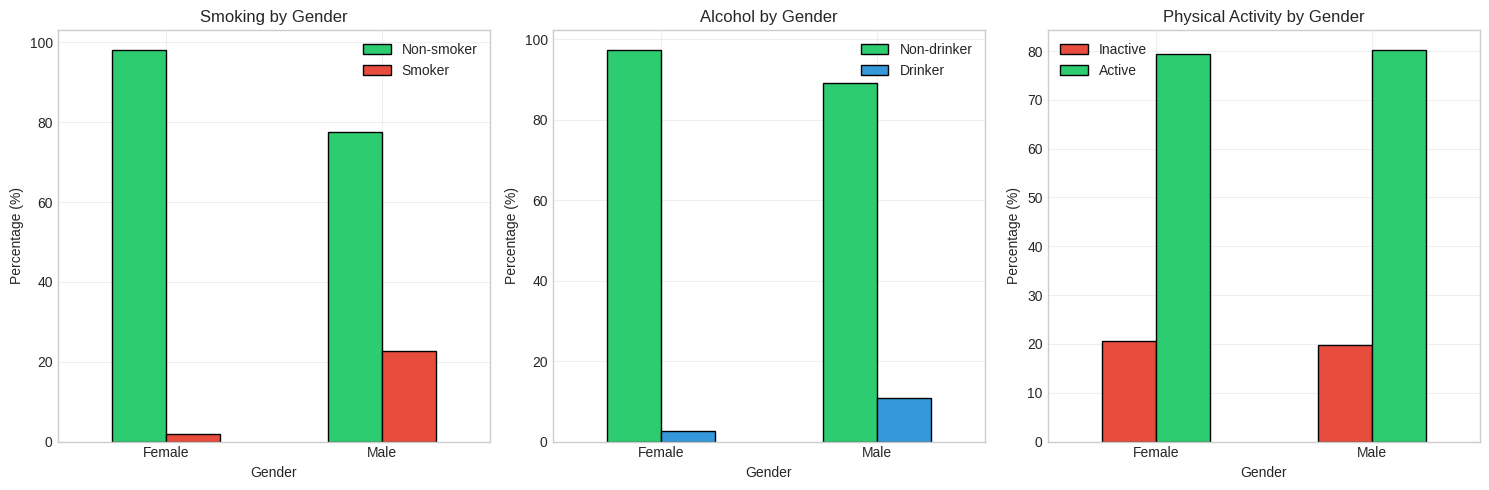

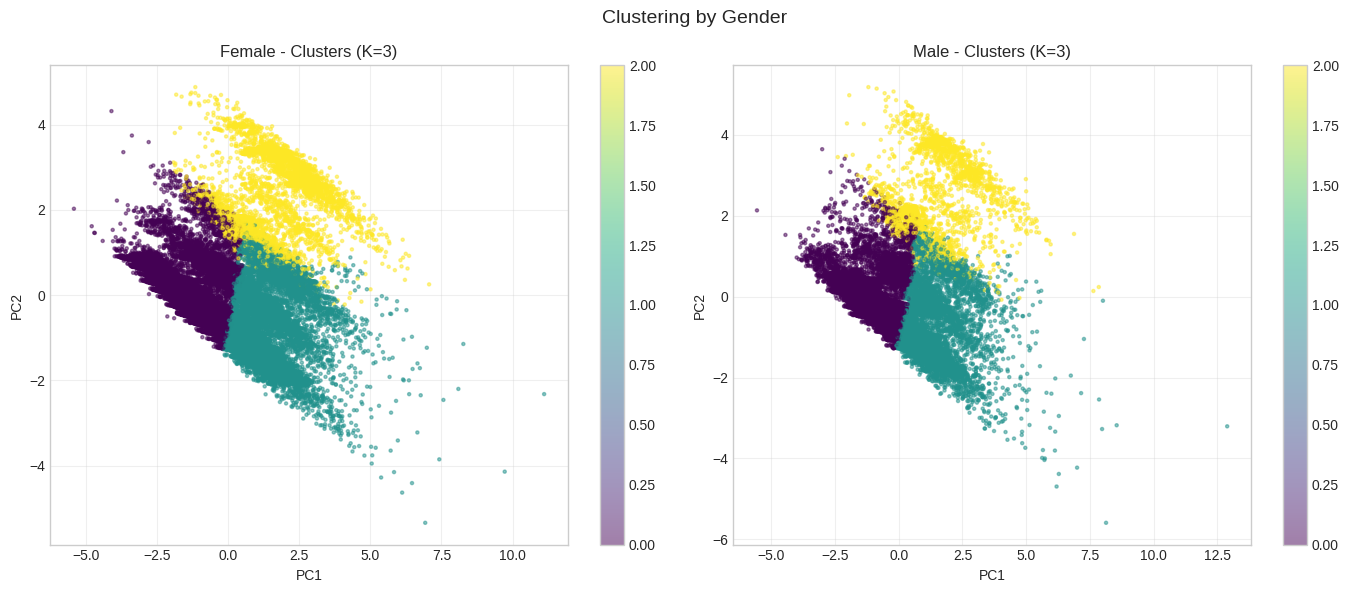

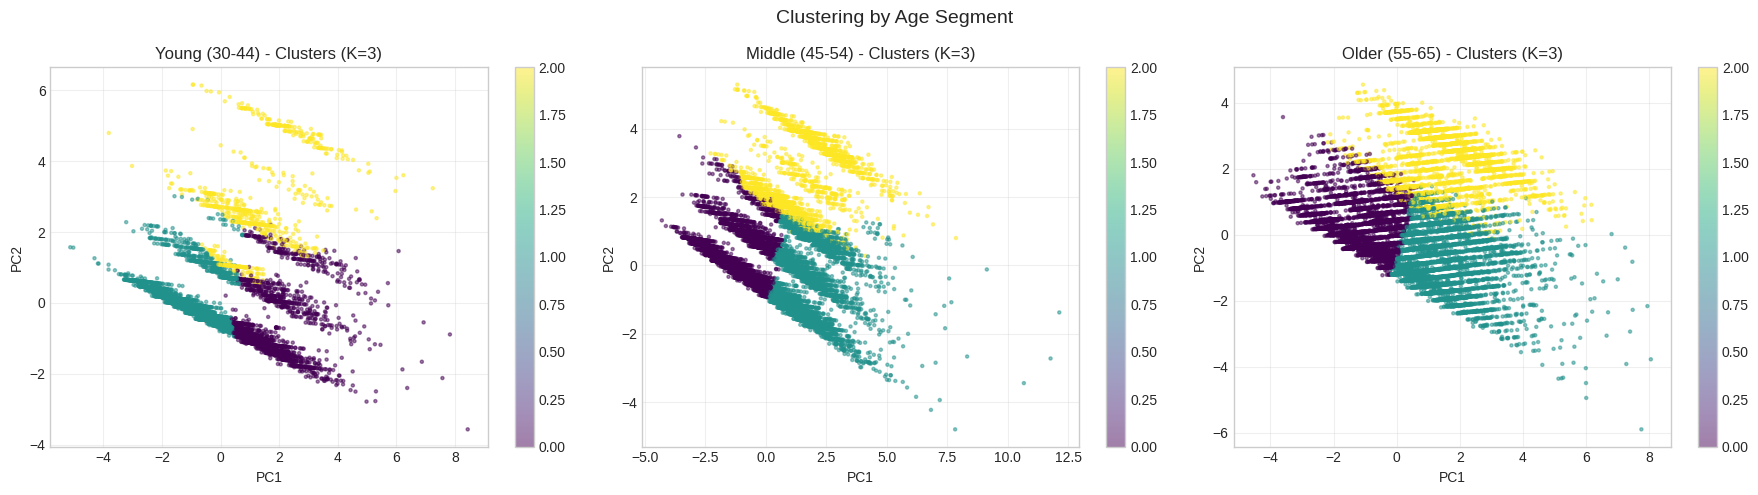


STRATIFIED ANALYSIS COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================================
# STRATIFIED ANALYSIS: GENDER AND AGE SEGMENTATION
# CONFOUNDERS, RISK FACTORS, AND CLUSTERING
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# DATA PREPARATION
# ============================================================================

df = pd.read_csv('/content/cardio_train_cleaned.csv')

# Calculate BMI and derived features
df['bmi'] = df['weight'] / ((df['height']/100) ** 2)
df['map'] = (2 * df['ap_lo'] + df['ap_hi']) / 3
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# Create age groups
df['age_group'] = pd.cut(df['age'], bins=[30, 40, 50, 60, 70],
                          labels=['30-39', '40-49', '50-59', '60-65'])

# Create gender label
df['gender_label'] = df['gender'].map({1: 'Female', 2: 'Male'})

# Create BMI categories
df['bmi_category'] = df['bmi'].apply(
    lambda x: 'Underweight' if x < 18.5
    else 'Normal' if x < 25
    else 'Overweight' if x < 30
    else 'Obese'
)

print("=" * 70)
print("STRATIFIED ANALYSIS: GENDER AND AGE SEGMENTATION")
print("=" * 70)

# ============================================================================
# CLASS: StratifiedAnalyzer
# ============================================================================

class StratifiedAnalyzer:
    def __init__(self, df):
        self.df = df.copy()
        self.female = df[df['gender'] == 1]
        self.male = df[df['gender'] == 2]

        # Age segments
        self.age_segments = {
            'Young (30-44)': df[(df['age'] >= 30) & (df['age'] <= 44)],
            'Middle (45-54)': df[(df['age'] >= 45) & (df['age'] <= 54)],
            'Older (55-65)': df[(df['age'] >= 55) & (df['age'] <= 65)]
        }

    # ========================================================================
    # 1. DISEASE DISTRIBUTION BY GENDER AND AGE
    # ========================================================================

    def disease_distribution_by_gender(self):
        print("\n" + "=" * 70)
        print("DISEASE DISTRIBUTION BY GENDER")
        print("=" * 70)

        print("\nOverall Disease Rate:")
        female_rate = self.female['cardio'].mean() * 100
        male_rate = self.male['cardio'].mean() * 100
        print(f"  Female: {female_rate:.1f}%")
        print(f"  Male: {male_rate:.1f}%")
        print(f"  Difference: {abs(female_rate - male_rate):.1f}%")

        print("\nDisease Rate by Age Group and Gender:")
        age_gender = self.df.groupby(['gender_label', 'age_group'])['cardio'].mean().unstack() * 100
        print(age_gender.round(1))

        return age_gender

    def disease_distribution_by_age_segments(self):
        print("\n" + "=" * 70)
        print("DISEASE DISTRIBUTION BY AGE SEGMENTS")
        print("=" * 70)

        for segment_name, segment_df in self.age_segments.items():
            rate = segment_df['cardio'].mean() * 100
            count = len(segment_df)
            female_rate = segment_df[segment_df['gender'] == 1]['cardio'].mean() * 100
            male_rate = segment_df[segment_df['gender'] == 2]['cardio'].mean() * 100
            print(f"\n{segment_name}:")
            print(f"  Total: {count:,} patients, Disease Rate: {rate:.1f}%")
            print(f"  Female: {female_rate:.1f}%, Male: {male_rate:.1f}%")

    # ========================================================================
    # 2. RISK FACTOR ANALYSIS BY STRATA
    # ========================================================================

    def risk_factors_by_gender(self):
        print("\n" + "=" * 70)
        print("RISK FACTORS BY GENDER")
        print("=" * 70)

        features = ['age', 'ap_hi', 'ap_lo', 'bmi', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

        print("\nAverage Values by Gender:")
        print("-" * 60)
        for feat in features:
            f_mean = self.female[feat].mean()
            m_mean = self.male[feat].mean()
            diff = m_mean - f_mean
            print(f"  {feat:12s}: Female={f_mean:.2f}, Male={m_mean:.2f}, Diff={diff:+.2f}")

        print("\nStatistical Significance (t-test):")
        for feat in features:
            t_stat, p_val = stats.ttest_ind(self.female[feat], self.male[feat])
            sig = "Significant" if p_val < 0.05 else "Not significant"
            print(f"  {feat:12s}: t={t_stat:.2f}, p={p_val:.4f} ({sig})")

    def risk_factors_by_age_segment(self):
        print("\n" + "=" * 70)
        print("RISK FACTORS BY AGE SEGMENT")
        print("=" * 70)

        features = ['ap_hi', 'ap_lo', 'bmi', 'cholesterol', 'gluc']

        results = {}
        for seg_name, seg_df in self.age_segments.items():
            results[seg_name] = []
            for feat in features:
                results[seg_name].append(seg_df[feat].mean())

        results_df = pd.DataFrame(results, index=features)
        print("\nAverage Values by Age Segment:")
        print(results_df.round(2))

        # ANOVA test
        print("\nANOVA Test (Age segments vs features):")
        for feat in features:
            groups = [seg_df[feat].values for seg_df in self.age_segments.values()]
            f_stat, p_val = stats.f_oneway(*groups)
            sig = "Significant" if p_val < 0.05 else "Not significant"
            print(f"  {feat:12s}: F={f_stat:.2f}, p={p_val:.4f} ({sig})")

    # ========================================================================
    # 3. CONFOUNDER ANALYSIS BY STRATA
    # ========================================================================

    def confounder_analysis_by_gender(self):
        print("\n" + "=" * 70)
        print("CONFOUNDER ANALYSIS BY GENDER")
        print("=" * 70)

        print("\nSmoking Effect by Gender:")
        for gender, gender_df, label in zip([1, 2], [self.female, self.male], ['Female', 'Male']):
            smoke_rate = gender_df[gender_df['smoke'] == 1]['cardio'].mean()
            nonsmoke_rate = gender_df[gender_df['smoke'] == 0]['cardio'].mean()
            effect = smoke_rate - nonsmoke_rate
            print(f"  {label}: Smoker={smoke_rate:.2%}, Non-smoker={nonsmoke_rate:.2%}, Effect={effect:.2%}")

        print("\nAlcohol Effect by Gender:")
        for gender, gender_df, label in zip([1, 2], [self.female, self.male], ['Female', 'Male']):
            alco_rate = gender_df[gender_df['alco'] == 1]['cardio'].mean()
            nonalco_rate = gender_df[gender_df['alco'] == 0]['cardio'].mean()
            effect = alco_rate - nonalco_rate
            print(f"  {label}: Drinker={alco_rate:.2%}, Non-drinker={nonalco_rate:.2%}, Effect={effect:.2%}")

    def confounder_analysis_by_age_segment(self):
        print("\n" + "=" * 70)
        print("CONFOUNDER ANALYSIS BY AGE SEGMENT")
        print("=" * 70)

        print("\nSmoking Effect by Age Segment:")
        for seg_name, seg_df in self.age_segments.items():
            smoke_df = seg_df[seg_df['smoke'] == 1]
            nonsmoke_df = seg_df[seg_df['smoke'] == 0]
            if len(smoke_df) > 0 and len(nonsmoke_df) > 0:
                smoke_rate = smoke_df['cardio'].mean()
                nonsmoke_rate = nonsmoke_df['cardio'].mean()
                effect = smoke_rate - nonsmoke_rate
                print(f"  {seg_name}: Smoker={smoke_rate:.2%}, Non-smoker={nonsmoke_rate:.2%}, Effect={effect:.2%}")
            else:
                print(f"  {seg_name}: Insufficient data")

        print("\nAlcohol Effect by Age Segment:")
        for seg_name, seg_df in self.age_segments.items():
            alco_df = seg_df[seg_df['alco'] == 1]
            nonalco_df = seg_df[seg_df['alco'] == 0]
            if len(alco_df) > 0 and len(nonalco_df) > 0:
                alco_rate = alco_df['cardio'].mean()
                nonalco_rate = nonalco_df['cardio'].mean()
                effect = alco_rate - nonalco_rate
                print(f"  {seg_name}: Drinker={alco_rate:.2%}, Non-drinker={nonalco_rate:.2%}, Effect={effect:.2%}")
            else:
                print(f"  {seg_name}: Insufficient data")

    # ========================================================================
    # 4. CLUSTERING BY GENDER
    # ========================================================================

    def clustering_by_gender(self, n_clusters=3):
        print("\n" + "=" * 70)
        print(f"CLUSTERING BY GENDER (K-Means, K={n_clusters})")
        print("=" * 70)

        features = ['age', 'ap_hi', 'ap_lo', 'bmi', 'cholesterol', 'gluc']

        for gender, gender_df, label in zip([1, 2], [self.female, self.male], ['Female', 'Male']):
            print(f"\n{label} Subgroup:")
            print(f"  Sample size: {len(gender_df):,}")

            # Prepare data
            X = gender_df[features].copy()
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            # K-Means clustering
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X_scaled)

            # Silhouette score
            sil_score = silhouette_score(X_scaled, labels)
            print(f"  Silhouette Score: {sil_score:.4f}")

            # Cluster characteristics
            gender_df['cluster'] = labels
            print(f"\n  Cluster Characteristics:")
            for cluster in range(n_clusters):
                cluster_data = gender_df[gender_df['cluster'] == cluster]
                size = len(cluster_data)
                disease_rate = cluster_data['cardio'].mean() * 100
                avg_age = cluster_data['age'].mean()
                avg_bp = cluster_data['ap_hi'].mean()
                avg_bmi = cluster_data['bmi'].mean()
                print(f"\n    Cluster {cluster}:")
                print(f"      Size: {size:,} ({size/len(gender_df)*100:.1f}%)")
                print(f"      Disease Rate: {disease_rate:.1f}%")
                print(f"      Avg Age: {avg_age:.1f}")
                print(f"      Avg SBP: {avg_bp:.1f}")
                print(f"      Avg BMI: {avg_bmi:.1f}")

    # ========================================================================
    # 5. CLUSTERING BY AGE SEGMENT
    # ========================================================================

    def clustering_by_age_segment(self, n_clusters=3):
        print("\n" + "=" * 70)
        print(f"CLUSTERING BY AGE SEGMENT (K-Means, K={n_clusters})")
        print("=" * 70)

        features = ['ap_hi', 'ap_lo', 'bmi', 'cholesterol', 'gluc']

        for seg_name, seg_df in self.age_segments.items():
            print(f"\n{seg_name}:")
            print(f"  Sample size: {len(seg_df):,}")

            # Prepare data
            X = seg_df[features].copy()
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            # K-Means clustering
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X_scaled)

            # Silhouette score
            sil_score = silhouette_score(X_scaled, labels)
            print(f"  Silhouette Score: {sil_score:.4f}")

            # Cluster characteristics
            seg_df['cluster'] = labels
            print(f"\n  Cluster Characteristics:")
            for cluster in range(n_clusters):
                cluster_data = seg_df[seg_df['cluster'] == cluster]
                size = len(cluster_data)
                disease_rate = cluster_data['cardio'].mean() * 100
                avg_bp = cluster_data['ap_hi'].mean()
                avg_bmi = cluster_data['bmi'].mean()
                avg_chol = cluster_data['cholesterol'].mean()
                print(f"\n    Cluster {cluster}:")
                print(f"      Size: {size:,} ({size/len(seg_df)*100:.1f}%)")
                print(f"      Disease Rate: {disease_rate:.1f}%")
                print(f"      Avg SBP: {avg_bp:.1f}")
                print(f"      Avg BMI: {avg_bmi:.1f}")
                print(f"      Avg Cholesterol: {avg_chol:.2f}")

# ============================================================================
# CLASS: StratifiedVisualizer
# ============================================================================

class StratifiedVisualizer:
    def __init__(self, df):
        self.df = df.copy()
        self.female = df[df['gender'] == 1]
        self.male = df[df['gender'] == 2]
        plt.style.use('seaborn-v0_8-whitegrid')

    def plot_disease_by_gender_age(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Disease rate by age group and gender
        age_gender = self.df.groupby(['gender_label', 'age_group'])['cardio'].mean().unstack() * 100
        age_gender.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
        axes[0].set_xlabel('Gender')
        axes[0].set_ylabel('Disease Rate (%)')
        axes[0].set_title('Disease Rate by Gender and Age Group')
        axes[0].legend(title='Age Group')
        axes[0].tick_params(axis='x', rotation=0)
        axes[0].grid(True, alpha=0.3)

        # Gender distribution by age group
        age_gender_count = pd.crosstab(self.df['age_group'], self.df['gender_label'])
        age_gender_count_pct = age_gender_count.div(age_gender_count.sum(axis=1), axis=0) * 100
        age_gender_count_pct.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
        axes[1].set_xlabel('Age Group')
        axes[1].set_ylabel('Percentage (%)')
        axes[1].set_title('Gender Distribution by Age Group')
        axes[1].legend()
        axes[1].tick_params(axis='x', rotation=0)
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/disease_by_gender_age.png', dpi=150)
        plt.show()

    def plot_risk_factors_by_gender(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        features = ['age', 'ap_hi', 'ap_lo', 'bmi', 'cholesterol', 'gluc']
        titles = ['Age (years)', 'Systolic BP (mmHg)', 'Diastolic BP (mmHg)',
                  'BMI (kg/m²)', 'Cholesterol (1-3)', 'Glucose (1-3)']

        for idx, (feat, title) in enumerate(zip(features, titles)):
            ax = axes[idx // 3, idx % 3]
            data = [self.female[feat], self.male[feat]]
            ax.boxplot(data, labels=['Female', 'Male'], patch_artist=True,
                      boxprops=dict(facecolor='lightblue'))
            ax.set_title(title)
            ax.grid(True, alpha=0.3)

            # Add t-test result
            t_stat, p_val = stats.ttest_ind(self.female[feat], self.male[feat])
            sig = 'p<0.001' if p_val < 0.001 else f'p={p_val:.3f}'
            ax.text(0.5, 0.95, f'test: {sig}', transform=ax.transAxes,
                   ha='center', va='top', fontsize=9, style='italic')

        plt.suptitle('Risk Factors Distribution by Gender', fontsize=14)
        plt.tight_layout()
        plt.savefig('/content/risk_factors_by_gender.png', dpi=150)
        plt.show()

    def plot_risk_factors_by_age_segment(self):
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        features = ['ap_hi', 'ap_lo', 'bmi', 'cholesterol', 'gluc']
        titles = ['Systolic BP (mmHg)', 'Diastolic BP (mmHg)', 'BMI (kg/m²)',
                  'Cholesterol (1-3)', 'Glucose (1-3)']

        segment_names = ['Young (30-44)', 'Middle (45-54)', 'Older (55-65)']
        segment_colors = ['#2ecc71', '#f39c12', '#e74c3c']
        segments = [self.df[(self.df['age'] >= 30) & (self.df['age'] <= 44)],
                    self.df[(self.df['age'] >= 45) & (self.df['age'] <= 54)],
                    self.df[(self.df['age'] >= 55) & (self.df['age'] <= 65)]]

        for idx, (feat, title) in enumerate(zip(features, titles)):
            ax = axes[idx // 3, idx % 3]
            data = [seg[feat] for seg in segments]
            ax.boxplot(data, labels=segment_names, patch_artist=True,
                      boxprops=dict(facecolor='lightblue'))
            ax.set_title(title)
            ax.grid(True, alpha=0.3)

            # Add ANOVA result
            groups = [seg[feat].values for seg in segments]
            f_stat, p_val = stats.f_oneway(*groups)
            sig = 'p<0.001' if p_val < 0.001 else f'p={p_val:.3f}'
            ax.text(0.5, 0.95, f'ANOVA: {sig}', transform=ax.transAxes,
                   ha='center', va='top', fontsize=9, style='italic')

        plt.suptitle('Risk Factors by Age Segment', fontsize=14)
        plt.tight_layout()
        plt.savefig('/content/risk_factors_by_age.png', dpi=150)
        plt.show()

    def plot_lifestyle_by_gender(self):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        # Smoking
        smoke_gender = pd.crosstab(self.df['gender_label'], self.df['smoke'], normalize='index') * 100
        smoke_gender.columns = ['Non-smoker', 'Smoker']
        smoke_gender.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
        axes[0].set_title('Smoking by Gender')
        axes[0].set_ylabel('Percentage (%)')
        axes[0].set_xlabel('Gender')
        axes[0].tick_params(axis='x', rotation=0)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        # Alcohol
        alco_gender = pd.crosstab(self.df['gender_label'], self.df['alco'], normalize='index') * 100
        alco_gender.columns = ['Non-drinker', 'Drinker']
        alco_gender.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#3498db'], edgecolor='black')
        axes[1].set_title('Alcohol by Gender')
        axes[1].set_ylabel('Percentage (%)')
        axes[1].set_xlabel('Gender')
        axes[1].tick_params(axis='x', rotation=0)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        # Physical Activity
        active_gender = pd.crosstab(self.df['gender_label'], self.df['active'], normalize='index') * 100
        active_gender.columns = ['Inactive', 'Active']
        active_gender.plot(kind='bar', ax=axes[2], color=['#e74c3c', '#2ecc71'], edgecolor='black')
        axes[2].set_title('Physical Activity by Gender')
        axes[2].set_ylabel('Percentage (%)')
        axes[2].set_xlabel('Gender')
        axes[2].tick_params(axis='x', rotation=0)
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/lifestyle_by_gender.png', dpi=150)
        plt.show()

    def plot_clustering_by_gender(self, n_clusters=3):
        features = ['age', 'ap_hi', 'ap_lo', 'bmi', 'cholesterol', 'gluc']

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        for idx, (gender_df, label, ax) in enumerate(zip([self.female, self.male],
                                                          ['Female', 'Male'], axes)):
            # Prepare data
            X = gender_df[features].copy()
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            # K-Means clustering
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X_scaled)

            # PCA for visualization
            pca = PCA(n_components=2)
            X_pca = pca.fit_transform(X_scaled)

            # Plot clusters
            scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.5, s=5)
            ax.set_title(f'{label} - Clusters (K={n_clusters})')
            ax.set_xlabel('PC1')
            ax.set_ylabel('PC2')
            ax.grid(True, alpha=0.3)
            plt.colorbar(scatter, ax=ax)

        plt.suptitle('Clustering by Gender', fontsize=14)
        plt.tight_layout()
        plt.savefig('/content/clustering_by_gender.png', dpi=150)
        plt.show()

    def plot_clustering_by_age_segment(self, n_clusters=3):
        features = ['ap_hi', 'ap_lo', 'bmi', 'cholesterol', 'gluc']
        segment_names = ['Young (30-44)', 'Middle (45-54)', 'Older (55-65)']
        segments = [self.df[(self.df['age'] >= 30) & (self.df['age'] <= 44)],
                    self.df[(self.df['age'] >= 45) & (self.df['age'] <= 54)],
                    self.df[(self.df['age'] >= 55) & (self.df['age'] <= 65)]]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        for idx, (seg_df, seg_name, ax) in enumerate(zip(segments, segment_names, axes)):
            # Prepare data
            X = seg_df[features].copy()
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            # K-Means clustering
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            labels = kmeans.fit_predict(X_scaled)

            # PCA for visualization
            pca = PCA(n_components=2)
            X_pca = pca.fit_transform(X_scaled)

            # Plot clusters
            scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.5, s=5)
            ax.set_title(f'{seg_name} - Clusters (K={n_clusters})')
            ax.set_xlabel('PC1')
            ax.set_ylabel('PC2')
            ax.grid(True, alpha=0.3)
            plt.colorbar(scatter, ax=ax)

        plt.suptitle('Clustering by Age Segment', fontsize=14)
        plt.tight_layout()
        plt.savefig('/content/clustering_by_age.png', dpi=150)
        plt.show()

    def plot_all_visualizations(self):
        self.plot_disease_by_gender_age()
        self.plot_risk_factors_by_gender()
        self.plot_risk_factors_by_age_segment()
        self.plot_lifestyle_by_gender()
        self.plot_clustering_by_gender(n_clusters=3)
        self.plot_clustering_by_age_segment(n_clusters=3)

# ============================================================================
# MAIN EXECUTION
# ============================================================================

# Initialize analyzer
analyzer = StratifiedAnalyzer(df)

# Run all analyses
analyzer.disease_distribution_by_gender()
analyzer.disease_distribution_by_age_segments()
analyzer.risk_factors_by_gender()
analyzer.risk_factors_by_age_segment()
analyzer.confounder_analysis_by_gender()
analyzer.confounder_analysis_by_age_segment()
analyzer.clustering_by_gender(n_clusters=3)
analyzer.clustering_by_age_segment(n_clusters=3)

# Visualize
visualizer = StratifiedVisualizer(df)
visualizer.plot_all_visualizations()

print("\n" + "=" * 70)
print("STRATIFIED ANALYSIS COMPLETED SUCCESSFULLY")
print("=" * 70)

 1-  MODEL TRAINING EXPERIMENTS

CARDIOVASCULAR DISEASE - COMPLETE MODEL TRAINING EXPERIMENTS
DATASET INFORMATION
Shape: 64,871 rows, 19 columns

Target distribution:
cardio
1    33001
0    31870
Name: count, dtype: int64
cardio
1    50.87173
0    49.12827
Name: proportion, dtype: float64

✅ BMI added to dataset
Final dataset: 64,871 rows, 19 columns

TRAINING MODELS

────────────────────────────────────────────────────────────────────────────────
FEATURE SET: Set 1 (Minimal - 3)
Features (3): ['ap_hi', 'age', 'bmi']
────────────────────────────────────────────────────────────────────────────────
Training: 51,896 samples
Testing: 12,975 samples

Training Gradient Boosting... Done!
  AUC: 0.7832 | Acc: 0.7163 | F1: 0.7139 | Time: 5.84s

Training XGBoost... Done!
  AUC: 0.7829 | Acc: 0.7165 | F1: 0.7131 | Time: 0.73s

Training LightGBM... Done!
  AUC: 0.7830 | Acc: 0.7159 | F1: 0.7133 | Time: 0.23s

Training Random Forest... Done!
  AUC: 0.7810 | Acc: 0.7134 | F1: 0.7106 | Time: 3.49s

──────────────────────────────────

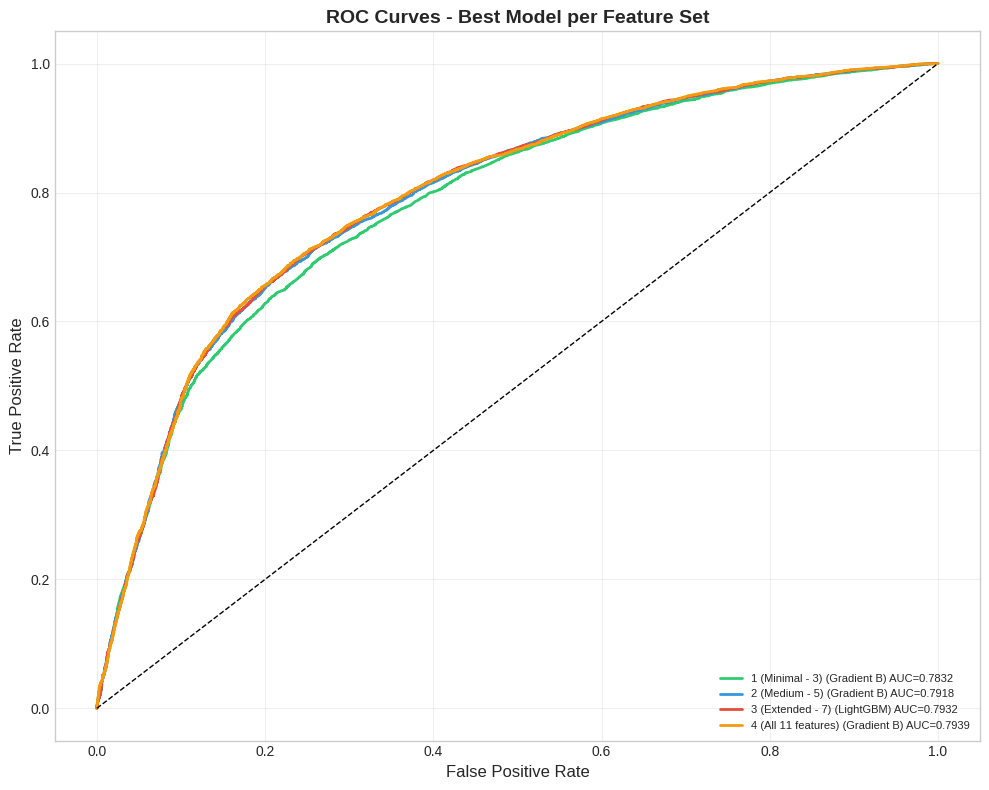

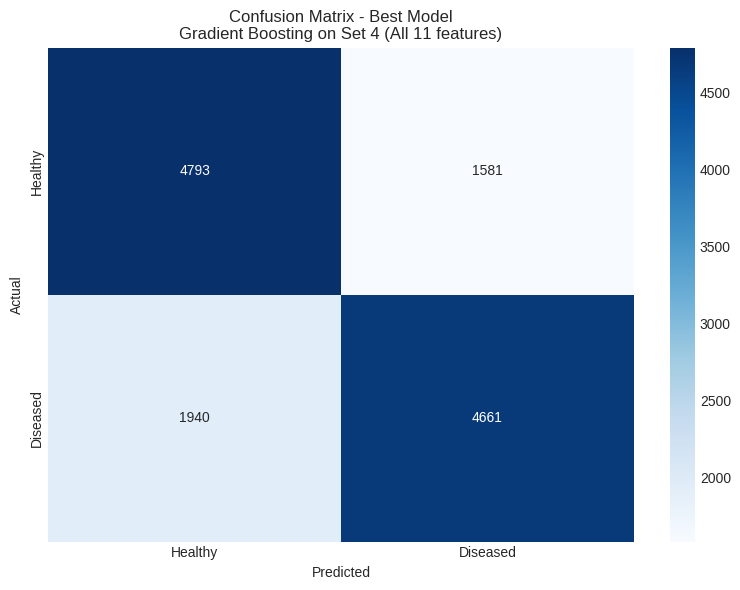

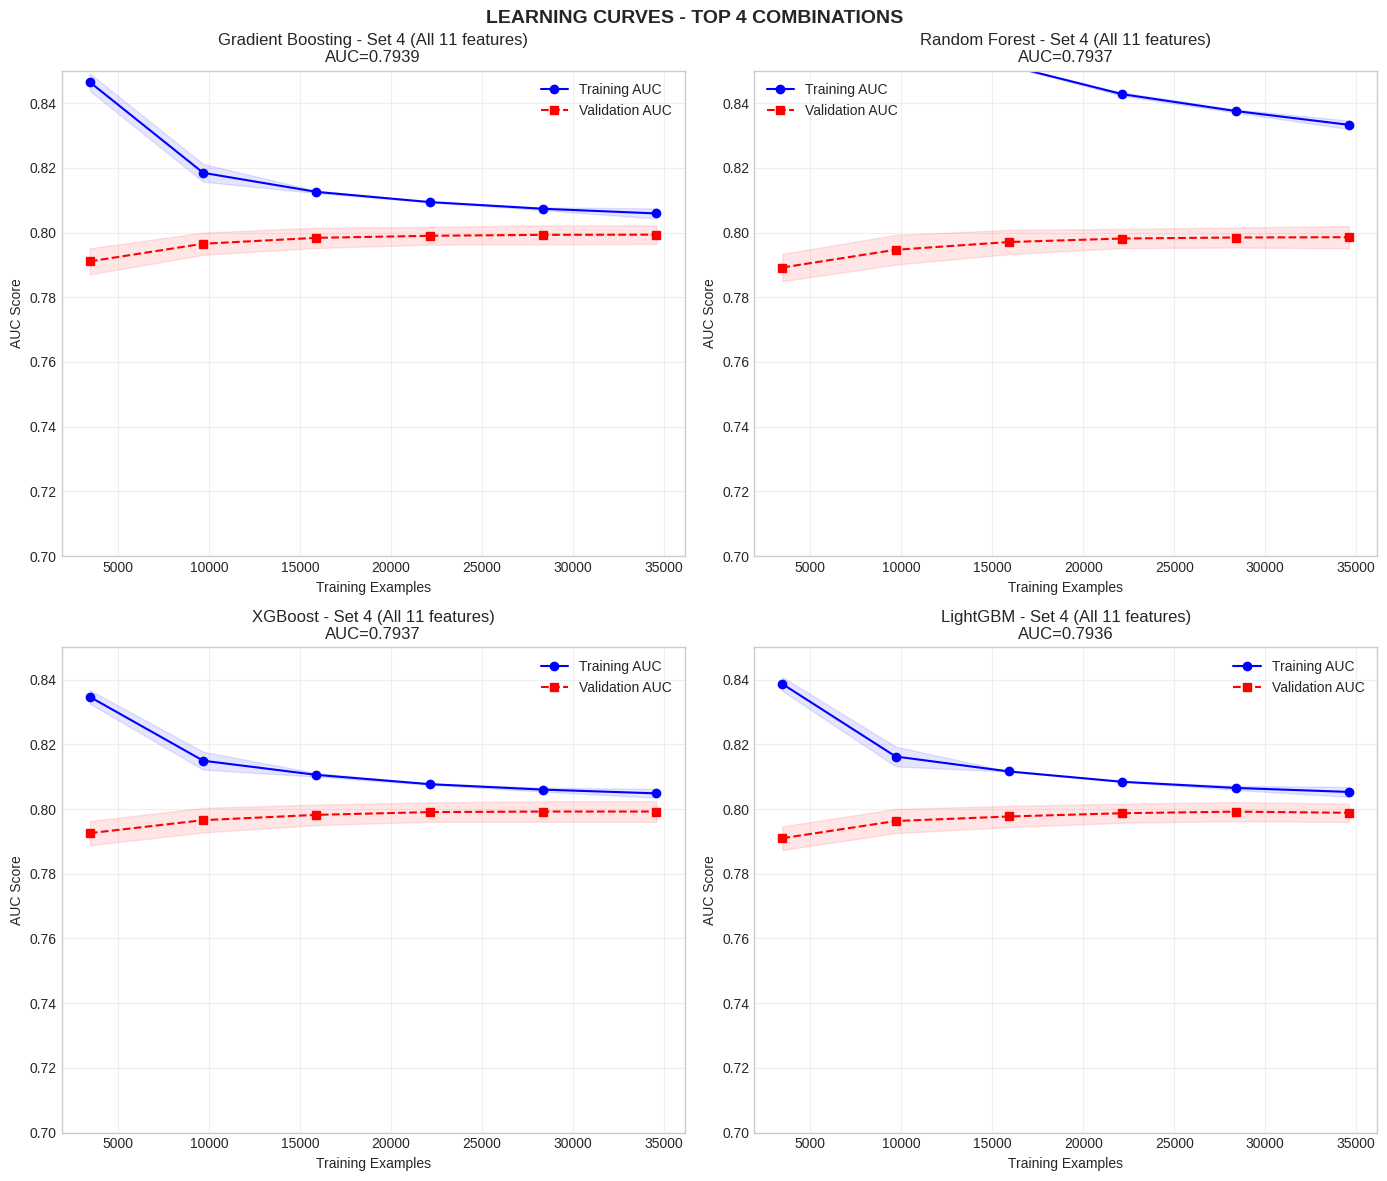

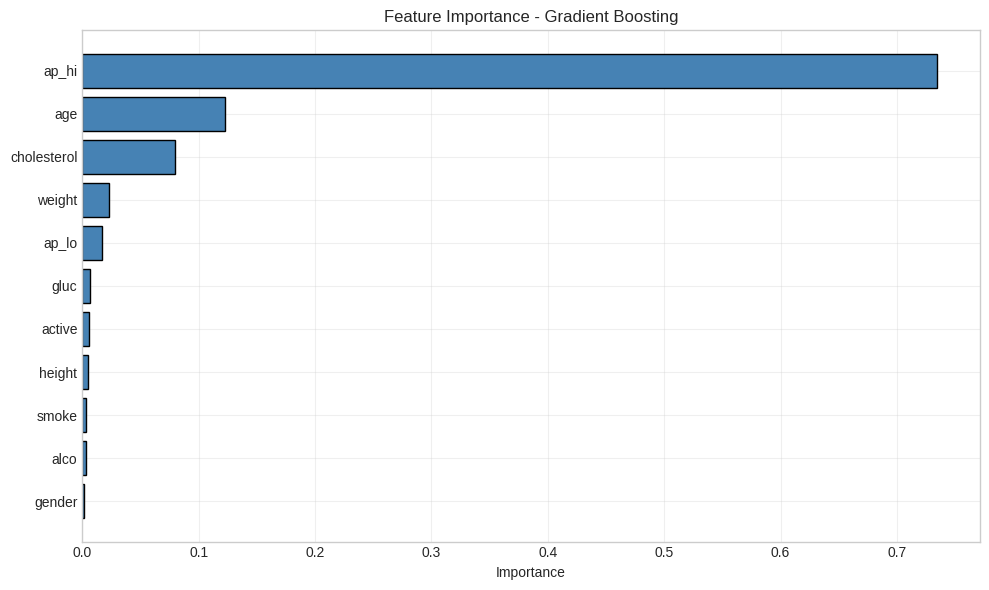


✅ Results saved to: model_results.csv

EXPERIMENTS COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================================
# COMPLETE MODEL TRAINING EXPERIMENTS - Without HYPERPARAMETER TUNING
# Cardiovascular Disease Dataset (Kaggle)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             average_precision_score, matthews_corrcoef)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CLASS: DataLoader
# ============================================================================

class DataLoader:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

    def load_data(self):
        self.df = pd.read_csv(self.file_path)
        return self.df

    def get_info(self):
        print("=" * 80)
        print("DATASET INFORMATION")
        print("=" * 80)
        print(f"Shape: {self.df.shape[0]:,} rows, {self.df.shape[1]} columns")
        print(f"\nTarget distribution:")
        print(self.df['cardio'].value_counts())
        print(self.df['cardio'].value_counts(normalize=True) * 100)

# ============================================================================
# CLASS: FeatureEngineer
# ============================================================================

class FeatureEngineer:
    def __init__(self, df):
        self.df = df.copy()

    def add_bmi(self):
        self.df['bmi'] = self.df['weight'] / ((self.df['height'] / 100) ** 2)
        return self

    def get_data(self):
        return self.df

# ============================================================================
# CLASS: ModelTrainer
# ============================================================================

class ModelTrainer:
    def __init__(self, df, feature_sets, algorithms, random_state=42, test_size=0.2):
        self.df = df
        self.feature_sets = feature_sets
        self.algorithms = algorithms
        self.random_state = random_state
        self.test_size = test_size
        self.splits = {}
        self.results = []
        self.trained_models = {}
        self.best_combination = None

    def prepare_splits(self):
        for set_name, features in self.feature_sets.items():
            X = self.df[features]
            y = self.df['cardio']
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
            )
            self.splits[set_name] = {
                'X_train': X_train,
                'X_test': X_test,
                'y_train': y_train,
                'y_test': y_test,
                'features': features
            }
        return self

    def train_all(self):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)

        for set_name, split in self.splits.items():
            X_train = split['X_train']
            X_test = split['X_test']
            y_train = split['y_train']
            y_test = split['y_test']
            features = split['features']

            print(f"\n{'─'*80}")
            print(f"FEATURE SET: {set_name}")
            print(f"Features ({len(features)}): {features}")
            print(f"{'─'*80}")
            print(f"Training: {X_train.shape[0]:,} samples")
            print(f"Testing: {X_test.shape[0]:,} samples")

            for name, model in self.algorithms.items():
                print(f"\nTraining {name}...", end=" ")
                start_time = time.time()

                # Clone model to avoid reusing fitted models
                from sklearn.base import clone
                model_clone = clone(model)
                model_clone.fit(X_train, y_train)
                train_time = time.time() - start_time

                y_pred = model_clone.predict(X_test)
                y_pred_proba = model_clone.predict_proba(X_test)[:, 1]

                accuracy = accuracy_score(y_test, y_pred)
                precision = precision_score(y_test, y_pred)
                recall = recall_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred)
                auc = roc_auc_score(y_test, y_pred_proba)
                mcc = matthews_corrcoef(y_test, y_pred)
                ap = average_precision_score(y_test, y_pred_proba)

                tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                npv = tn / (tn + fn) if (tn + fn) > 0 else 0

                cv_scores = cross_val_score(model_clone, X_train, y_train, cv=cv, scoring='roc_auc')

                self.results.append({
                    'Feature_Set': set_name,
                    'Algorithm': name,
                    'N_Features': len(features),
                    'Accuracy': accuracy,
                    'Precision': precision,
                    'Recall': recall,
                    'Specificity': specificity,
                    'NPV': npv,
                    'F1_Score': f1,
                    'AUC': auc,
                    'MCC': mcc,
                    'AP': ap,
                    'CV_Mean': cv_scores.mean(),
                    'CV_Std': cv_scores.std(),
                    'Train_Time': train_time,
                    'TP': tp,
                    'TN': tn,
                    'FP': fp,
                    'FN': fn
                })

                key = f"{name}_{set_name}"
                self.trained_models[key] = model_clone

                print(f"Done!")
                print(f"  AUC: {auc:.4f} | Acc: {accuracy:.4f} | F1: {f1:.4f} | Time: {train_time:.2f}s")

        return self

    def get_best(self):
        best = max(self.results, key=lambda x: x['AUC'])
        self.best_combination = best
        return best

    def get_results_df(self):
        return pd.DataFrame(self.results)

    def get_pivot_table(self, metric='AUC'):
        df = self.get_results_df()
        return df.pivot(index='Feature_Set', columns='Algorithm', values=metric)

# ============================================================================
# CLASS: ModelEvaluator
# ============================================================================

class ModelEvaluator:
    def __init__(self, trainer):
        self.trainer = trainer
        self.results_df = trainer.get_results_df()
        self.best = trainer.get_best()
        self.best_key = f"{self.best['Algorithm']}_{self.best['Feature_Set']}"
        self.best_model = trainer.trained_models[self.best_key]
        self.best_split = trainer.splits[self.best['Feature_Set']]

    def print_summary(self):
        print("\n" + "=" * 80)
        print("BEST COMBINATION")
        print("=" * 80)
        print(f"Feature Set: {self.best['Feature_Set']}")
        print(f"Algorithm: {self.best['Algorithm']}")
        print(f"AUC: {self.best['AUC']:.4f}")
        print(f"Accuracy: {self.best['Accuracy']:.4f} ({self.best['Accuracy']*100:.2f}%)")
        print(f"F1 Score: {self.best['F1_Score']:.4f}")
        print(f"CV AUC: {self.best['CV_Mean']:.4f} (+/- {self.best['CV_Std']:.4f})")
        print(f"Training Time: {self.best['Train_Time']:.2f}s")
        print(f"Features: {self.trainer.splits[self.best['Feature_Set']]['features']}")

    def print_pivot_tables(self):
        print("\n" + "=" * 80)
        print("RESULTS SUMMARY")
        print("=" * 80)

        metrics = ['AUC', 'Accuracy', 'F1_Score', 'Train_Time']
        for metric in metrics:
            pivot = self.trainer.get_pivot_table(metric)
            print(f"\n{metric} by Feature Set and Algorithm:")
            print("-" * 60)
            print(pivot.round(4))

    def print_overfitting_analysis(self):
        print("\n" + "=" * 80)
        print("OVERFITTING ANALYSIS")
        print("=" * 80)
        print("\nComparing CV AUC vs Test AUC:")
        print("-" * 80)
        print(f"{'Feature Set':<25} {'Algorithm':<20} {'CV AUC':<12} {'Test AUC':<12} {'Diff':<10} {'Risk':<10}")
        print("-" * 80)

        for _, row in self.results_df.iterrows():
            diff = row['CV_Mean'] - row['AUC']
            risk = "High" if abs(diff) > 0.05 else "Moderate" if abs(diff) > 0.025 else "Low"
            print(f"{row['Feature_Set']:<25} {row['Algorithm']:<20} {row['CV_Mean']:.4f}       {row['AUC']:.4f}       {diff:+.4f}    {risk}")

    def print_classification_report(self):
        print("\n" + "=" * 80)
        print("DETAILED CLASSIFICATION REPORT - BEST MODEL")
        print("=" * 80)

        X_test = self.best_split['X_test']
        y_test = self.best_split['y_test']
        y_pred = self.best_model.predict(X_test)

        print(f"\n{'─'*60}")
        print(f"Model: {self.best['Algorithm']}")
        print(f"Feature Set: {self.best['Feature_Set']}")
        print(f"{'─'*60}")

        print("\nClassification Report:")
        print("-" * 50)
        print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Diseased (1)']))

        tn, fp, fn, tp = self.best['TN'], self.best['FP'], self.best['FN'], self.best['TP']
        print("\nConfusion Matrix:")
        print("-" * 40)
        print(f"  True Negatives:  {tn:6,}  (Correctly predicted Healthy)")
        print(f"  False Positives: {fp:6,}  (Wrongly predicted Diseased)")
        print(f"  False Negatives: {fn:6,}  (Wrongly predicted Healthy)")
        print(f"  True Positives:  {tp:6,}  (Correctly predicted Diseased)")

    def print_feature_ranking(self):
        print("\n" + "=" * 80)
        print("FEATURE SET RANKING (Average AUC across all algorithms)")
        print("=" * 80)

        avg_auc = self.results_df.groupby('Feature_Set')['AUC'].mean().sort_values(ascending=False)
        for set_name, avg in avg_auc.items():
            print(f"  {set_name}: {avg:.4f}")

    def print_final_ranking(self):
        print("\n" + "=" * 80)
        print("FINAL RANKING (by AUC)")
        print("=" * 80)

        top_10 = self.results_df.sort_values('AUC', ascending=False).head(10)
        for i, (_, row) in enumerate(top_10.iterrows()):
            medal = "🥇" if i == 0 else "🥈" if i == 1 else "🥉" if i == 2 else "  "
            print(f"{medal} {i+1:2d}. {row['Algorithm']:<18} | {row['Feature_Set']:<25} | AUC={row['AUC']:.4f} | Acc={row['Accuracy']:.4f}")

    def plot_roc_curves(self):
        fig, ax = plt.subplots(figsize=(10, 8))
        colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

        for idx, (set_name, split) in enumerate(self.trainer.splits.items()):
            set_results = self.results_df[self.results_df['Feature_Set'] == set_name]
            best_in_set = set_results.loc[set_results['AUC'].idxmax()]
            key = f"{best_in_set['Algorithm']}_{set_name}"
            model = self.trainer.trained_models[key]

            X_test = split['X_test']
            y_test = split['y_test']
            y_pred_proba = model.predict_proba(X_test)[:, 1]

            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            auc = roc_auc_score(y_test, y_pred_proba)

            label = f"{set_name.replace('Set ', '')} ({best_in_set['Algorithm'][:10]}) AUC={auc:.4f}"
            ax.plot(fpr, tpr, color=colors[idx % len(colors)], lw=2, label=label)

        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_title('ROC Curves - Best Model per Feature Set', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('/content/roc_curves.png', dpi=150)
        plt.show()

    def plot_confusion_matrix(self):
        X_test = self.best_split['X_test']
        y_test = self.best_split['y_test']
        y_pred = self.best_model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Healthy', 'Diseased'],
                    yticklabels=['Healthy', 'Diseased'])
        ax.set_title(f'Confusion Matrix - Best Model\n{self.best["Algorithm"]} on {self.best["Feature_Set"]}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        plt.tight_layout()
        plt.savefig('/content/confusion_matrix.png', dpi=150)
        plt.show()

    def plot_learning_curves(self):
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))

        top_4 = self.results_df.sort_values('AUC', ascending=False).head(4)

        for i, (_, row) in enumerate(top_4.iterrows()):
            ax = axes[i // 2, i % 2]
            key = f"{row['Algorithm']}_{row['Feature_Set']}"
            model = self.trainer.trained_models[key]

            X_train = self.trainer.splits[row['Feature_Set']]['X_train']
            y_train = self.trainer.splits[row['Feature_Set']]['y_train']

            train_sizes, train_scores, test_scores = learning_curve(
                model, X_train, y_train, cv=3, n_jobs=-1,
                train_sizes=np.linspace(0.1, 1.0, 6),
                scoring='roc_auc', random_state=42
            )

            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            test_mean = np.mean(test_scores, axis=1)
            test_std = np.std(test_scores, axis=1)

            ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
            ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
            ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training AUC')
            ax.plot(train_sizes, test_mean, 's--', color='red', label='Validation AUC')
            ax.set_xlabel('Training Examples')
            ax.set_ylabel('AUC Score')
            ax.set_title(f"{row['Algorithm']} - {row['Feature_Set']}\nAUC={row['AUC']:.4f}")
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0.7, 0.85)

        plt.suptitle('LEARNING CURVES - TOP 4 COMBINATIONS', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('/content/learning_curves.png', dpi=150)
        plt.show()

    def plot_feature_importance(self):
        if hasattr(self.best_model, 'feature_importances_'):
            features = self.trainer.splits[self.best['Feature_Set']]['features']
            importances = self.best_model.feature_importances_

            fig, ax = plt.subplots(figsize=(10, 6))
            imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
            imp_df = imp_df.sort_values('Importance', ascending=True)
            ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='black')
            ax.set_xlabel('Importance')
            ax.set_title(f'Feature Importance - {self.best["Algorithm"]}')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('/content/feature_importance.png', dpi=150)
            plt.show()

    def run_all_visualizations(self):
        self.plot_roc_curves()
        self.plot_confusion_matrix()
        self.plot_learning_curves()
        self.plot_feature_importance()

    def save_results(self):
        self.results_df.to_csv('/content/model_results.csv', index=False)
        print("\n✅ Results saved to: model_results.csv")

# ============================================================================
# CLASS: ExperimentRunner (Main Controller)
# ============================================================================

class ExperimentRunner:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None
        self.trainer = None
        self.evaluator = None

    def run(self):
        print("=" * 80)
        print("CARDIOVASCULAR DISEASE - COMPLETE MODEL TRAINING EXPERIMENTS")
        print("=" * 80)

        # Step 1: Load Data
        loader = DataLoader(self.file_path)
        self.df = loader.load_data()
        loader.get_info()

        # Step 2: Feature Engineering
        engineer = FeatureEngineer(self.df)
        engineer.add_bmi()
        self.df = engineer.get_data()
        print(f"\n✅ BMI added to dataset")
        print(f"Final dataset: {self.df.shape[0]:,} rows, {self.df.shape[1]} columns")

        # Step 3: Define Feature Sets
        feature_sets = {
            'Set 1 (Minimal - 3)': ['ap_hi', 'age', 'bmi'],
            'Set 2 (Medium - 5)': ['ap_hi', 'age', 'bmi', 'ap_lo', 'cholesterol'],
            'Set 3 (Extended - 7)': ['ap_hi', 'age', 'bmi', 'ap_lo', 'cholesterol', 'active', 'smoke'],
            'Set 4 (All 11 features)': ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                                        'cholesterol', 'gluc', 'smoke', 'alco', 'active']
        }

        # Step 4: Define Algorithms
        algorithms = {
            'Gradient Boosting': GradientBoostingClassifier(
                n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42
            ),
            'XGBoost': XGBClassifier(
                n_estimators=200, max_depth=3, learning_rate=0.05, subsample=1.0,
                colsample_bytree=0.8, random_state=42, n_jobs=-1,
                use_label_encoder=False, eval_metric='logloss'
            ),
            'LightGBM': LGBMClassifier(
                n_estimators=100, max_depth=3, learning_rate=0.1, num_leaves=15,
                subsample=0.8, random_state=42, n_jobs=-1, verbose=-1
            ),
            'Random Forest': RandomForestClassifier(
                n_estimators=200, max_depth=10, min_samples_split=5,
                min_samples_leaf=2, random_state=42, n_jobs=-1
            )
        }

        # Step 5: Train Models
        print("\n" + "=" * 80)
        print("TRAINING MODELS")
        print("=" * 80)

        self.trainer = ModelTrainer(self.df, feature_sets, algorithms)
        self.trainer.prepare_splits()
        self.trainer.train_all()

        # Step 6: Evaluate
        self.evaluator = ModelEvaluator(self.trainer)
        self.evaluator.print_summary()
        self.evaluator.print_pivot_tables()
        self.evaluator.print_overfitting_analysis()
        self.evaluator.print_classification_report()
        self.evaluator.print_feature_ranking()
        self.evaluator.print_final_ranking()

        # Step 7: Visualizations
        print("\n" + "=" * 80)
        print("GENERATING VISUALIZATIONS")
        print("=" * 80)
        self.evaluator.run_all_visualizations()

        # Step 8: Save Results
        self.evaluator.save_results()

        print("\n" + "=" * 80)
        print("EXPERIMENTS COMPLETED SUCCESSFULLY")
        print("=" * 80)

        return self.trainer, self.evaluator

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    runner = ExperimentRunner('/content/cardio_train_cleaned.csv')
    trainer, evaluator = runner.run()

COMPLETE MODEL TRAINING EXPERIMENTS WITH HYPERPARAMETER TUNING  

CARDIOVASCULAR DISEASE - COMPLETE MODEL TRAINING EXPERIMENTS
Hyperparameter Tuning: ENABLED (Optimized)
DATASET INFORMATION
Shape: 64,871 rows, 19 columns

Target distribution:
cardio
1    33001
0    31870
Name: count, dtype: int64
cardio
1    50.87173
0    49.12827
Name: proportion, dtype: float64

✅ BMI added to dataset
Final dataset: 64,871 rows, 19 columns

TRAINING MODELS

────────────────────────────────────────────────────────────────────────────────
FEATURE SET: Set 1 (Minimal - 3)
Features (3): ['ap_hi', 'age', 'bmi']
────────────────────────────────────────────────────────────────────────────────
Training: 51,896 samples
Testing: 12,975 samples

──────────────────────────────────────────────────
Algorithm: Gradient Boosting
──────────────────────────────────────────────────

  Optimizing Gradient Boosting...
    Best params: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.05}
    Best CV AUC: 0.7861
   

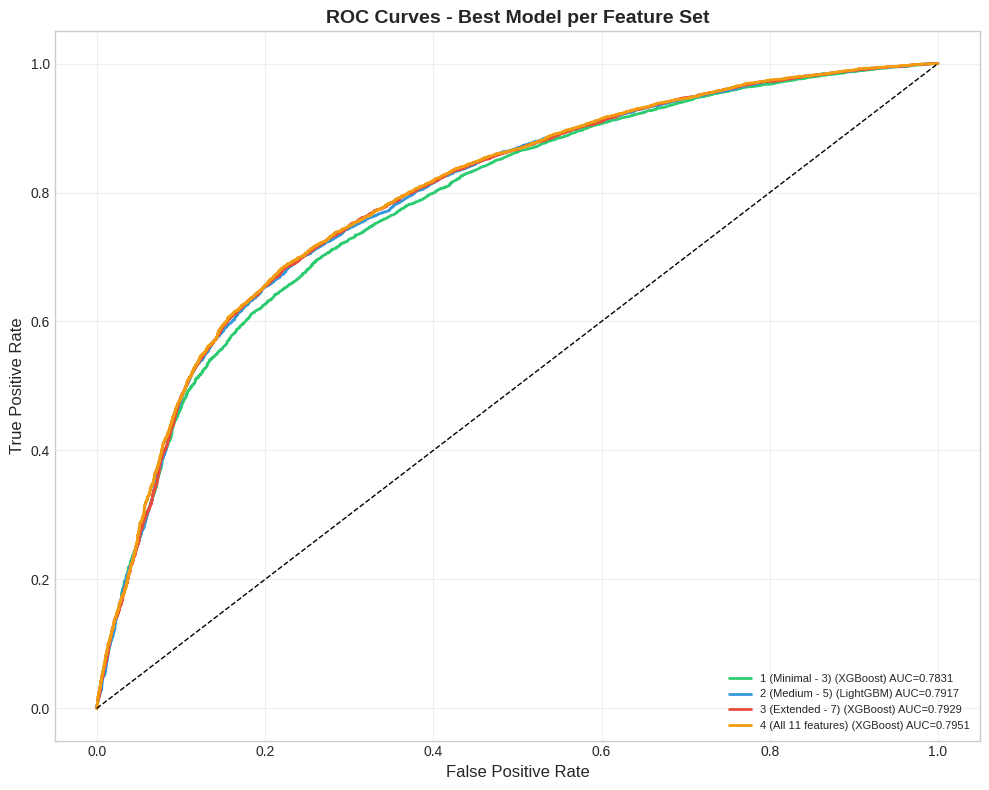

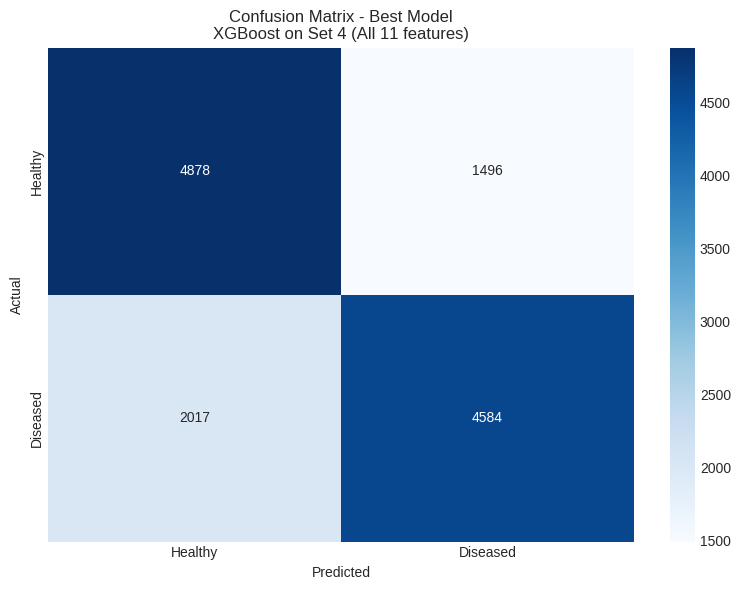

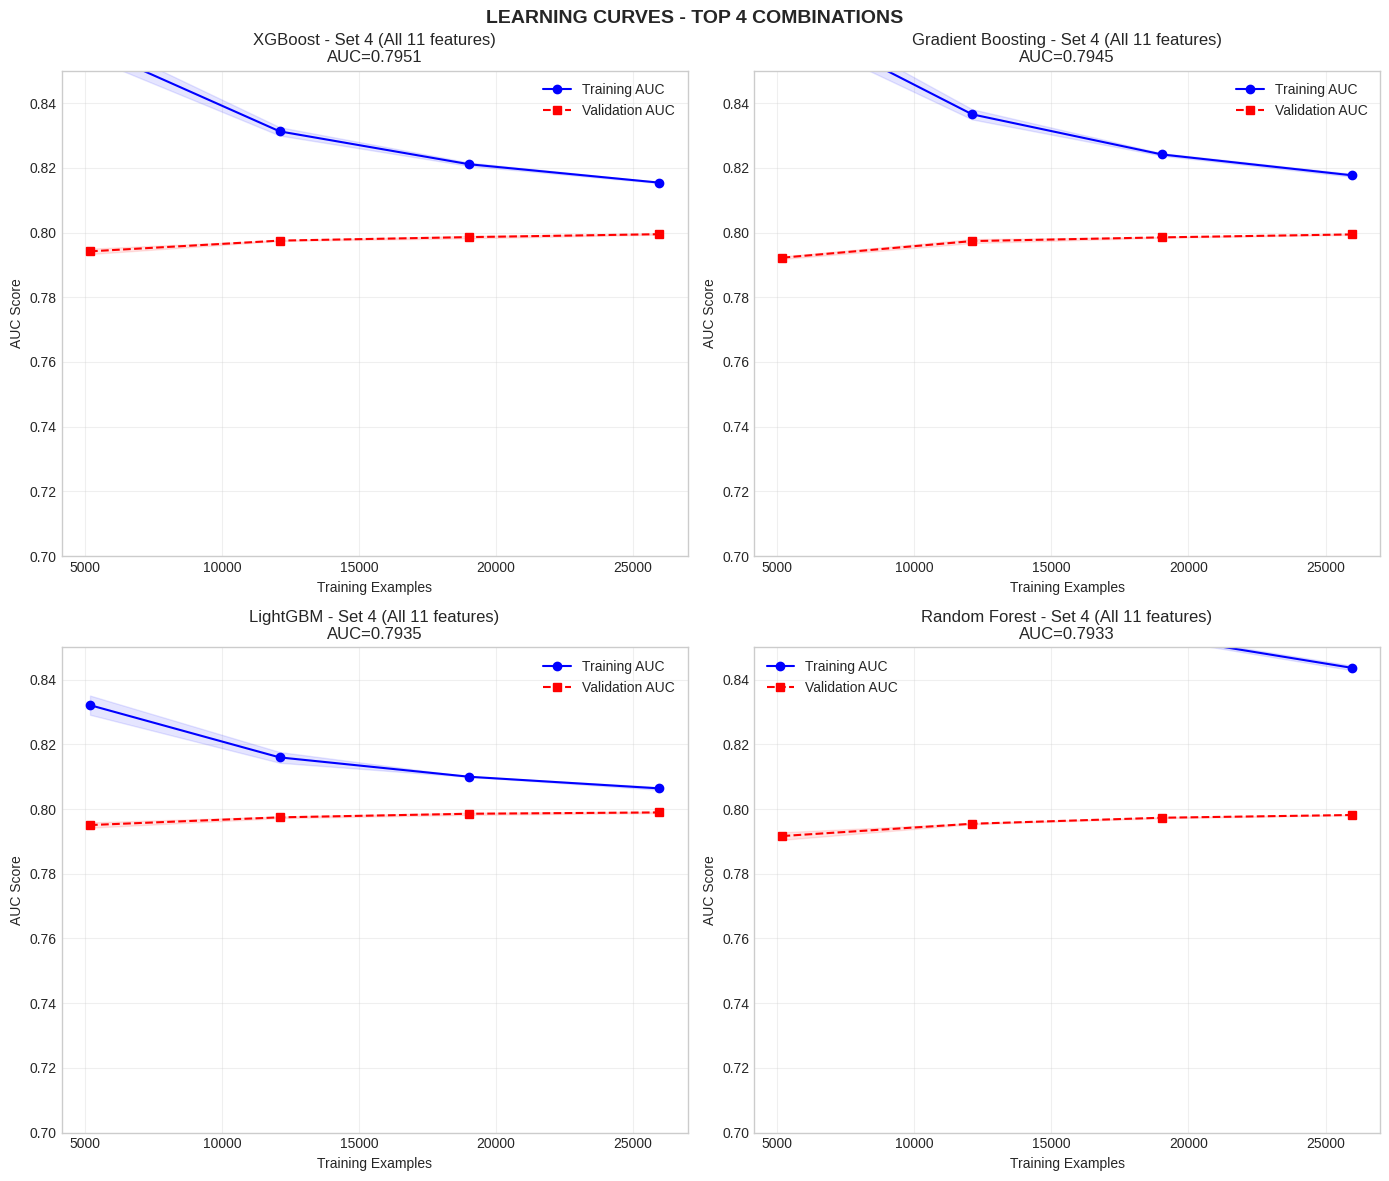

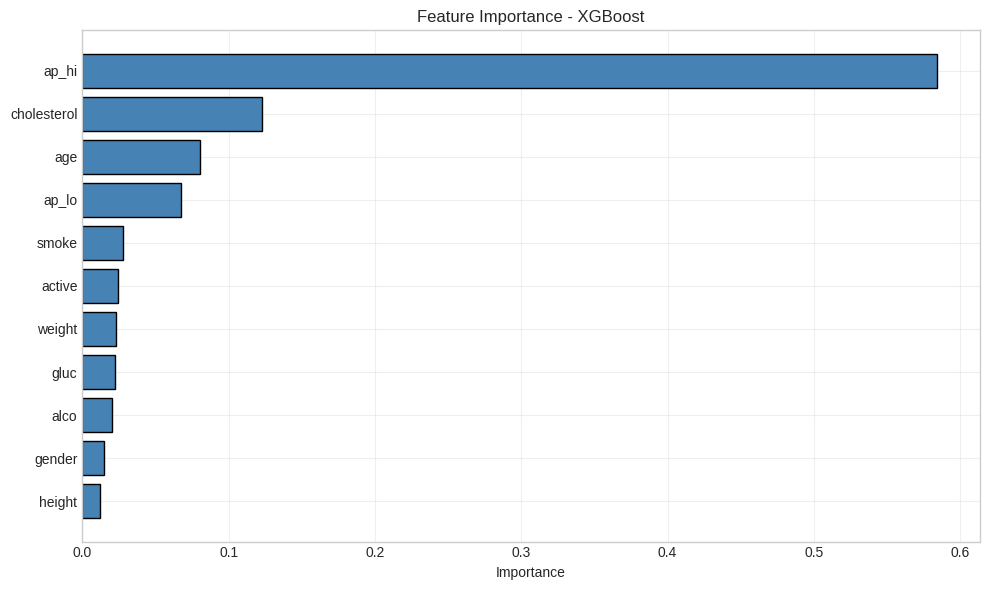


✅ Results saved to: model_results.csv

EXPERIMENTS COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================================
# COMPLETE MODEL TRAINING EXPERIMENTS WITH OPTIMIZED HYPERPARAMETER TUNING
# Cardiovascular Disease Dataset (Kaggle)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             average_precision_score, matthews_corrcoef)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
import time
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CLASS: DataLoader
# ============================================================================

class DataLoader:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

    def load_data(self):
        self.df = pd.read_csv(self.file_path)
        return self.df

    def get_info(self):
        print("=" * 80)
        print("DATASET INFORMATION")
        print("=" * 80)
        print(f"Shape: {self.df.shape[0]:,} rows, {self.df.shape[1]} columns")
        print(f"\nTarget distribution:")
        print(self.df['cardio'].value_counts())
        print(self.df['cardio'].value_counts(normalize=True) * 100)

# ============================================================================
# CLASS: FeatureEngineer
# ============================================================================

class FeatureEngineer:
    def __init__(self, df):
        self.df = df.copy()

    def add_bmi(self):
        self.df['bmi'] = self.df['weight'] / ((self.df['height'] / 100) ** 2)
        return self

    def get_data(self):
        return self.df

# ============================================================================
# CLASS: OptimizedHyperparameterTuner (Using RandomizedSearchCV for speed)
# ============================================================================

class OptimizedHyperparameterTuner:
    def __init__(self, random_state=42, n_iter=10):
        self.random_state = random_state
        self.n_iter = n_iter  # Number of random combinations to try

    def get_param_distributions(self):
        return {
            'Gradient Boosting': {
                'model': GradientBoostingClassifier(random_state=self.random_state),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [3, 5],
                    'learning_rate': [0.05, 0.1],
                    'subsample': [0.8, 1.0],
                    'min_samples_split': [2, 5],
                    'min_samples_leaf': [1, 2]
                },
                'scaled': False
            },
            'XGBoost': {
                'model': XGBClassifier(random_state=self.random_state, n_jobs=-1,
                                      use_label_encoder=False, eval_metric='logloss'),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [3, 5],
                    'learning_rate': [0.05, 0.1],
                    'subsample': [0.8, 1.0],
                    'colsample_bytree': [0.8, 1.0],
                    'reg_alpha': [0, 0.1, 1],
                    'reg_lambda': [0, 0.1, 1]
                },
                'scaled': False
            },
            'LightGBM': {
                'model': LGBMClassifier(random_state=self.random_state, n_jobs=-1, verbose=-1),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [3, 5],
                    'learning_rate': [0.05, 0.1],
                    'num_leaves': [15, 31],
                    'subsample': [0.8, 1.0],
                    'reg_alpha': [0, 0.1, 1],
                    'reg_lambda': [0, 0.1, 1]
                },
                'scaled': False
            },
            'Random Forest': {
                'model': RandomForestClassifier(random_state=self.random_state, n_jobs=-1),
                'params': {
                    'n_estimators': [100, 200],
                    'max_depth': [10, 15],
                    'min_samples_split': [2, 5],
                    'min_samples_leaf': [1, 2],
                    'max_features': ['sqrt', 'log2']
                },
                'scaled': False
            }
        }

    def tune_model(self, model_name, X_train, y_train, cv=3):
        param_dist = self.get_param_distributions()
        config = param_dist[model_name]

        print(f"\n  Optimizing {model_name}...")
        start_time = time.time()

        random_search = RandomizedSearchCV(
            estimator=config['model'],
            param_distributions=config['params'],
            n_iter=self.n_iter,
            cv=cv,
            scoring='roc_auc',
            n_jobs=-1,
            random_state=self.random_state,
            verbose=0
        )

        random_search.fit(X_train, y_train)
        tuning_time = time.time() - start_time

        print(f"    Best params: {random_search.best_params_}")
        print(f"    Best CV AUC: {random_search.best_score_:.4f}")
        print(f"    Tuning time: {tuning_time:.2f}s")

        return random_search.best_estimator_, random_search.best_params_, random_search.best_score_

# ============================================================================
# CLASS: ModelTrainer
# ============================================================================

class ModelTrainer:
    def __init__(self, df, feature_sets, algorithms, random_state=42, test_size=0.2, tune_hyperparams=False):
        self.df = df
        self.feature_sets = feature_sets
        self.algorithms = algorithms
        self.random_state = random_state
        self.test_size = test_size
        self.tune_hyperparams = tune_hyperparams
        self.splits = {}
        self.results = []
        self.trained_models = {}
        self.best_combination = None
        self.tuner = OptimizedHyperparameterTuner(random_state, n_iter=8)

    def prepare_splits(self):
        for set_name, features in self.feature_sets.items():
            X = self.df[features]
            y = self.df['cardio']
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
            )
            self.splits[set_name] = {
                'X_train': X_train,
                'X_test': X_test,
                'y_train': y_train,
                'y_test': y_test,
                'features': features
            }
        return self

    def train_all(self):
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=self.random_state)  # Reduced from 5 to 3

        for set_name, split in self.splits.items():
            X_train = split['X_train']
            X_test = split['X_test']
            y_train = split['y_train']
            y_test = split['y_test']
            features = split['features']

            print(f"\n{'─'*80}")
            print(f"FEATURE SET: {set_name}")
            print(f"Features ({len(features)}): {features}")
            print(f"{'─'*80}")
            print(f"Training: {X_train.shape[0]:,} samples")
            print(f"Testing: {X_test.shape[0]:,} samples")

            for name in self.algorithms.keys():
                print(f"\n{'─'*50}")
                print(f"Algorithm: {name}")
                print(f"{'─'*50}")

                start_time = time.time()

                # Hyperparameter tuning if enabled
                if self.tune_hyperparams:
                    best_model, best_params, best_cv_score = self.tuner.tune_model(name, X_train, y_train, cv=3)
                else:
                    # Use default model
                    best_model = self.algorithms[name]
                    best_params = "Default parameters"
                    best_cv_score = None
                    best_model.fit(X_train, y_train)

                train_time = time.time() - start_time

                # Clone model to avoid feature name issues
                from sklearn.base import clone
                model_clone = clone(best_model)
                model_clone.fit(X_train, y_train)

                y_pred = model_clone.predict(X_test)
                y_pred_proba = model_clone.predict_proba(X_test)[:, 1]

                accuracy = accuracy_score(y_test, y_pred)
                precision = precision_score(y_test, y_pred)
                recall = recall_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred)
                auc = roc_auc_score(y_test, y_pred_proba)
                mcc = matthews_corrcoef(y_test, y_pred)
                ap = average_precision_score(y_test, y_pred_proba)

                tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                npv = tn / (tn + fn) if (tn + fn) > 0 else 0

                cv_scores = cross_val_score(model_clone, X_train, y_train, cv=cv, scoring='roc_auc')

                self.results.append({
                    'Feature_Set': set_name,
                    'Algorithm': name,
                    'N_Features': len(features),
                    'Accuracy': accuracy,
                    'Precision': precision,
                    'Recall': recall,
                    'Specificity': specificity,
                    'NPV': npv,
                    'F1_Score': f1,
                    'AUC': auc,
                    'MCC': mcc,
                    'AP': ap,
                    'CV_Mean': cv_scores.mean(),
                    'CV_Std': cv_scores.std(),
                    'Train_Time': train_time,
                    'Best_Params': str(best_params),
                    'Best_CV_Score': best_cv_score,
                    'TP': tp,
                    'TN': tn,
                    'FP': fp,
                    'FN': fn
                })

                key = f"{name}_{set_name}"
                self.trained_models[key] = model_clone

                print(f"\n  ✅ Done!")
                print(f"  AUC: {auc:.4f} | Acc: {accuracy:.4f} | F1: {f1:.4f}")
                print(f"  CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
                print(f"  Time: {train_time:.2f}s")

        return self

    def get_best(self):
        best = max(self.results, key=lambda x: x['AUC'])
        self.best_combination = best
        return best

    def get_results_df(self):
        return pd.DataFrame(self.results)

    def get_pivot_table(self, metric='AUC'):
        df = self.get_results_df()
        return df.pivot(index='Feature_Set', columns='Algorithm', values=metric)

# ============================================================================
# CLASS: ModelEvaluator
# ============================================================================

class ModelEvaluator:
    def __init__(self, trainer):
        self.trainer = trainer
        self.results_df = trainer.get_results_df()
        self.best = trainer.get_best()
        self.best_key = f"{self.best['Algorithm']}_{self.best['Feature_Set']}"
        self.best_model = trainer.trained_models[self.best_key]
        self.best_split = trainer.splits[self.best['Feature_Set']]

    def print_summary(self):
        print("\n" + "=" * 80)
        print("BEST COMBINATION")
        print("=" * 80)
        print(f"Feature Set: {self.best['Feature_Set']}")
        print(f"Algorithm: {self.best['Algorithm']}")
        print(f"AUC: {self.best['AUC']:.4f}")
        print(f"Accuracy: {self.best['Accuracy']:.4f} ({self.best['Accuracy']*100:.2f}%)")
        print(f"F1 Score: {self.best['F1_Score']:.4f}")
        print(f"CV AUC: {self.best['CV_Mean']:.4f} (+/- {self.best['CV_Std']:.4f})")
        print(f"Training Time: {self.best['Train_Time']:.2f}s")
        print(f"Best Params: {self.best['Best_Params']}")
        print(f"Features: {self.trainer.splits[self.best['Feature_Set']]['features']}")

    def print_pivot_tables(self):
        print("\n" + "=" * 80)
        print("RESULTS SUMMARY")
        print("=" * 80)

        metrics = ['AUC', 'Accuracy', 'F1_Score', 'Train_Time']
        for metric in metrics:
            pivot = self.trainer.get_pivot_table(metric)
            print(f"\n{metric} by Feature Set and Algorithm:")
            print("-" * 60)
            print(pivot.round(4))

    def print_overfitting_analysis(self):
        print("\n" + "=" * 80)
        print("OVERFITTING ANALYSIS")
        print("=" * 80)
        print("\nComparing CV AUC vs Test AUC:")
        print("-" * 80)
        print(f"{'Feature Set':<25} {'Algorithm':<20} {'CV AUC':<12} {'Test AUC':<12} {'Diff':<10} {'Risk':<10}")
        print("-" * 80)

        for _, row in self.results_df.iterrows():
            diff = row['CV_Mean'] - row['AUC']
            risk = "High" if abs(diff) > 0.05 else "Moderate" if abs(diff) > 0.025 else "Low"
            print(f"{row['Feature_Set']:<25} {row['Algorithm']:<20} {row['CV_Mean']:.4f}       {row['AUC']:.4f}       {diff:+.4f}    {risk}")

    def print_classification_report(self):
        print("\n" + "=" * 80)
        print("DETAILED CLASSIFICATION REPORT - BEST MODEL")
        print("=" * 80)

        X_test = self.best_split['X_test']
        y_test = self.best_split['y_test']
        y_pred = self.best_model.predict(X_test)

        print(f"\n{'─'*60}")
        print(f"Model: {self.best['Algorithm']}")
        print(f"Feature Set: {self.best['Feature_Set']}")
        print(f"{'─'*60}")

        print("\nClassification Report:")
        print("-" * 50)
        print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Diseased (1)']))

        tn, fp, fn, tp = self.best['TN'], self.best['FP'], self.best['FN'], self.best['TP']
        print("\nConfusion Matrix:")
        print("-" * 40)
        print(f"  True Negatives:  {tn:6,}  (Correctly predicted Healthy)")
        print(f"  False Positives: {fp:6,}  (Wrongly predicted Diseased)")
        print(f"  False Negatives: {fn:6,}  (Wrongly predicted Healthy)")
        print(f"  True Positives:  {tp:6,}  (Correctly predicted Diseased)")

        print("\nMetrics Summary:")
        print("-" * 40)
        print(f"  Specificity: {self.best['Specificity']:.4f} ({self.best['Specificity']*100:.2f}%)")
        print(f"  NPV: {self.best['NPV']:.4f} ({self.best['NPV']*100:.2f}%)")
        print(f"  MCC: {self.best['MCC']:.4f}")
        print(f"  AP: {self.best['AP']:.4f}")

    def print_feature_ranking(self):
        print("\n" + "=" * 80)
        print("FEATURE SET RANKING (Average AUC across all algorithms)")
        print("=" * 80)

        avg_auc = self.results_df.groupby('Feature_Set')['AUC'].mean().sort_values(ascending=False)
        for set_name, avg in avg_auc.items():
            print(f"  {set_name}: {avg:.4f}")

    def print_final_ranking(self):
        print("\n" + "=" * 80)
        print("FINAL RANKING (by AUC)")
        print("=" * 80)

        top_10 = self.results_df.sort_values('AUC', ascending=False).head(10)
        for i, (_, row) in enumerate(top_10.iterrows()):
            medal = "🥇" if i == 0 else "🥈" if i == 1 else "🥉" if i == 2 else "  "
            print(f"{medal} {i+1:2d}. {row['Algorithm']:<18} | {row['Feature_Set']:<25} | AUC={row['AUC']:.4f} | Acc={row['Accuracy']:.4f}")

    def plot_roc_curves(self):
        fig, ax = plt.subplots(figsize=(10, 8))
        colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']

        for idx, (set_name, split) in enumerate(self.trainer.splits.items()):
            set_results = self.results_df[self.results_df['Feature_Set'] == set_name]
            best_in_set = set_results.loc[set_results['AUC'].idxmax()]
            key = f"{best_in_set['Algorithm']}_{set_name}"
            model = self.trainer.trained_models[key]

            X_test = split['X_test']
            y_test = split['y_test']
            y_pred_proba = model.predict_proba(X_test)[:, 1]

            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            auc = roc_auc_score(y_test, y_pred_proba)

            label = f"{set_name.replace('Set ', '')} ({best_in_set['Algorithm'][:10]}) AUC={auc:.4f}"
            ax.plot(fpr, tpr, color=colors[idx % len(colors)], lw=2, label=label)

        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_title('ROC Curves - Best Model per Feature Set', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('/content/roc_curves.png', dpi=150)
        plt.show()

    def plot_confusion_matrix(self):
        X_test = self.best_split['X_test']
        y_test = self.best_split['y_test']
        y_pred = self.best_model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Healthy', 'Diseased'],
                    yticklabels=['Healthy', 'Diseased'])
        ax.set_title(f'Confusion Matrix - Best Model\n{self.best["Algorithm"]} on {self.best["Feature_Set"]}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        plt.tight_layout()
        plt.savefig('/content/confusion_matrix.png', dpi=150)
        plt.show()

    def plot_learning_curves(self):
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))

        top_4 = self.results_df.sort_values('AUC', ascending=False).head(4)

        for i, (_, row) in enumerate(top_4.iterrows()):
            ax = axes[i // 2, i % 2]
            key = f"{row['Algorithm']}_{row['Feature_Set']}"
            model = self.trainer.trained_models[key]

            X_train = self.trainer.splits[row['Feature_Set']]['X_train']
            y_train = self.trainer.splits[row['Feature_Set']]['y_train']

            train_sizes, train_scores, test_scores = learning_curve(
                model, X_train, y_train, cv=2, n_jobs=-1,  # Reduced CV for speed
                train_sizes=np.linspace(0.2, 1.0, 4),
                scoring='roc_auc', random_state=42
            )

            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            test_mean = np.mean(test_scores, axis=1)
            test_std = np.std(test_scores, axis=1)

            ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
            ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
            ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training AUC')
            ax.plot(train_sizes, test_mean, 's--', color='red', label='Validation AUC')
            ax.set_xlabel('Training Examples')
            ax.set_ylabel('AUC Score')
            ax.set_title(f"{row['Algorithm']} - {row['Feature_Set']}\nAUC={row['AUC']:.4f}")
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0.7, 0.85)

        plt.suptitle('LEARNING CURVES - TOP 4 COMBINATIONS', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('/content/learning_curves.png', dpi=150)
        plt.show()

    def plot_feature_importance(self):
        if hasattr(self.best_model, 'feature_importances_'):
            features = self.trainer.splits[self.best['Feature_Set']]['features']
            importances = self.best_model.feature_importances_

            fig, ax = plt.subplots(figsize=(10, 6))
            imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
            imp_df = imp_df.sort_values('Importance', ascending=True)
            ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='black')
            ax.set_xlabel('Importance')
            ax.set_title(f'Feature Importance - {self.best["Algorithm"]}')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('/content/feature_importance.png', dpi=150)
            plt.show()

    def run_all_visualizations(self):
        self.plot_roc_curves()
        self.plot_confusion_matrix()
        self.plot_learning_curves()
        self.plot_feature_importance()

    def save_results(self):
        self.results_df.to_csv('/content/model_results.csv', index=False)
        print("\n✅ Results saved to: model_results.csv")

# ============================================================================
# CLASS: ExperimentRunner (Main Controller)
# ============================================================================

class ExperimentRunner:
    def __init__(self, file_path, tune_hyperparams=False):
        self.file_path = file_path
        self.df = None
        self.trainer = None
        self.evaluator = None
        self.tune_hyperparams = tune_hyperparams

    def run(self):
        print("=" * 80)
        print("CARDIOVASCULAR DISEASE - COMPLETE MODEL TRAINING EXPERIMENTS")
        print(f"Hyperparameter Tuning: {'ENABLED (Optimized)' if self.tune_hyperparams else 'DISABLED'}")
        print("=" * 80)

        # Step 1: Load Data
        loader = DataLoader(self.file_path)
        self.df = loader.load_data()
        loader.get_info()

        # Step 2: Feature Engineering
        engineer = FeatureEngineer(self.df)
        engineer.add_bmi()
        self.df = engineer.get_data()
        print(f"\n✅ BMI added to dataset")
        print(f"Final dataset: {self.df.shape[0]:,} rows, {self.df.shape[1]} columns")

        # Step 3: Define Feature Sets
        feature_sets = {
            'Set 1 (Minimal - 3)': ['ap_hi', 'age', 'bmi'],
            'Set 2 (Medium - 5)': ['ap_hi', 'age', 'bmi', 'ap_lo', 'cholesterol'],
            'Set 3 (Extended - 7)': ['ap_hi', 'age', 'bmi', 'ap_lo', 'cholesterol', 'active', 'smoke'],
            'Set 4 (All 11 features)': ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                                        'cholesterol', 'gluc', 'smoke', 'alco', 'active']
        }

        # Step 4: Define Base Algorithms
        base_algorithms = {
            'Gradient Boosting': GradientBoostingClassifier(random_state=42),
            'XGBoost': XGBClassifier(random_state=42, n_jobs=-1,
                                     use_label_encoder=False, eval_metric='logloss'),
            'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
            'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1)
        }

        # Step 5: Train Models
        print("\n" + "=" * 80)
        print("TRAINING MODELS")
        print("=" * 80)

        self.trainer = ModelTrainer(
            self.df,
            feature_sets,
            base_algorithms,
            tune_hyperparams=self.tune_hyperparams
        )
        self.trainer.prepare_splits()
        self.trainer.train_all()

        # Step 6: Evaluate
        self.evaluator = ModelEvaluator(self.trainer)
        self.evaluator.print_summary()
        self.evaluator.print_pivot_tables()
        self.evaluator.print_overfitting_analysis()
        self.evaluator.print_classification_report()
        self.evaluator.print_feature_ranking()
        self.evaluator.print_final_ranking()

        # Step 7: Visualizations
        print("\n" + "=" * 80)
        print("GENERATING VISUALIZATIONS")
        print("=" * 80)
        self.evaluator.run_all_visualizations()

        # Step 8: Save Results
        self.evaluator.save_results()

        print("\n" + "=" * 80)
        print("EXPERIMENTS COMPLETED SUCCESSFULLY")
        print("=" * 80)

        return self.trainer, self.evaluator

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Run with optimized hyperparameter tuning
    runner = ExperimentRunner('/content/cardio_train_cleaned.csv', tune_hyperparams=True)
    trainer, evaluator = runner.run()

CARDIOVASCULAR DISEASE - COMPLETE MODEL TRAINING EXPERIMENTS
Hyperparameter Tuning: ENABLED
DATASET INFORMATION
Shape: 68,647 rows, 12 columns

Target distribution:
cardio
0    34678
1    33969
Name: count, dtype: int64
cardio
0    50.51641
1    49.48359
Name: proportion, dtype: float64

✅ BMI added to dataset
Final dataset: 68,647 rows, 13 columns

TRAINING MODELS

────────────────────────────────────────────────────────────────────────────────
FEATURE SET: Set 1 (Minimal - 3)
Features (3): ['ap_hi', 'age', 'bmi']
────────────────────────────────────────────────────────────────────────────────
Training: 54,917 samples
Testing: 13,730 samples

Training KNN... Done!
  AUC: 0.7685 | Acc: 0.7070 | F1: 0.6945 | Time: 37.42s

Training Decision Tree... Done!
  AUC: 0.7780 | Acc: 0.7160 | F1: 0.7063 | Time: 32.24s

Training Gradient Boosting... Done!
  AUC: 0.7821 | Acc: 0.7185 | F1: 0.7043 | Time: 3.26s

Training XGBoost... Done!
  AUC: 0.7762 | Acc: 0.7142 | F1: 0.6980 | Time: 0.65s

Traini

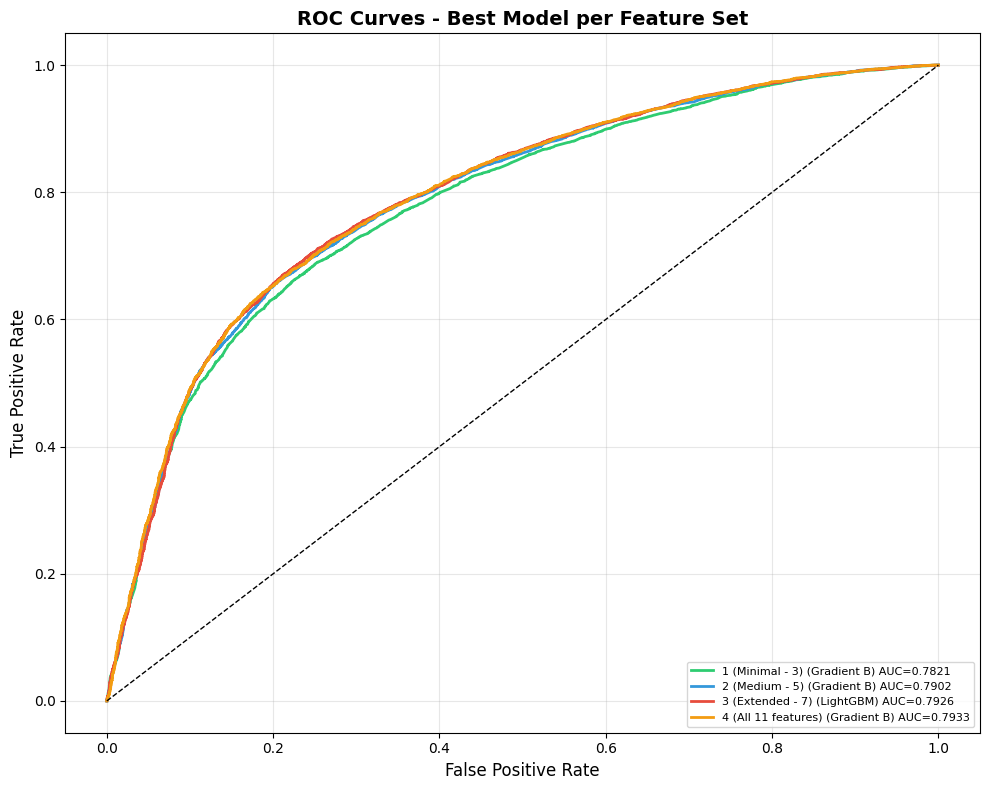

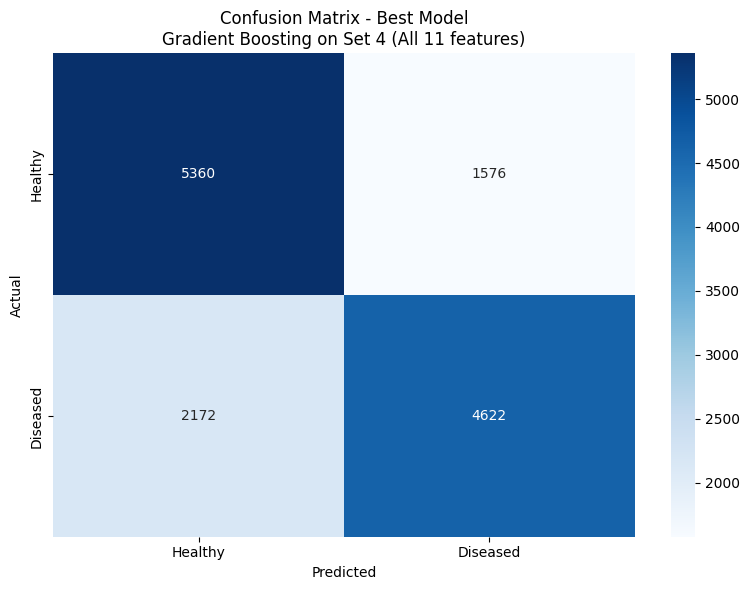

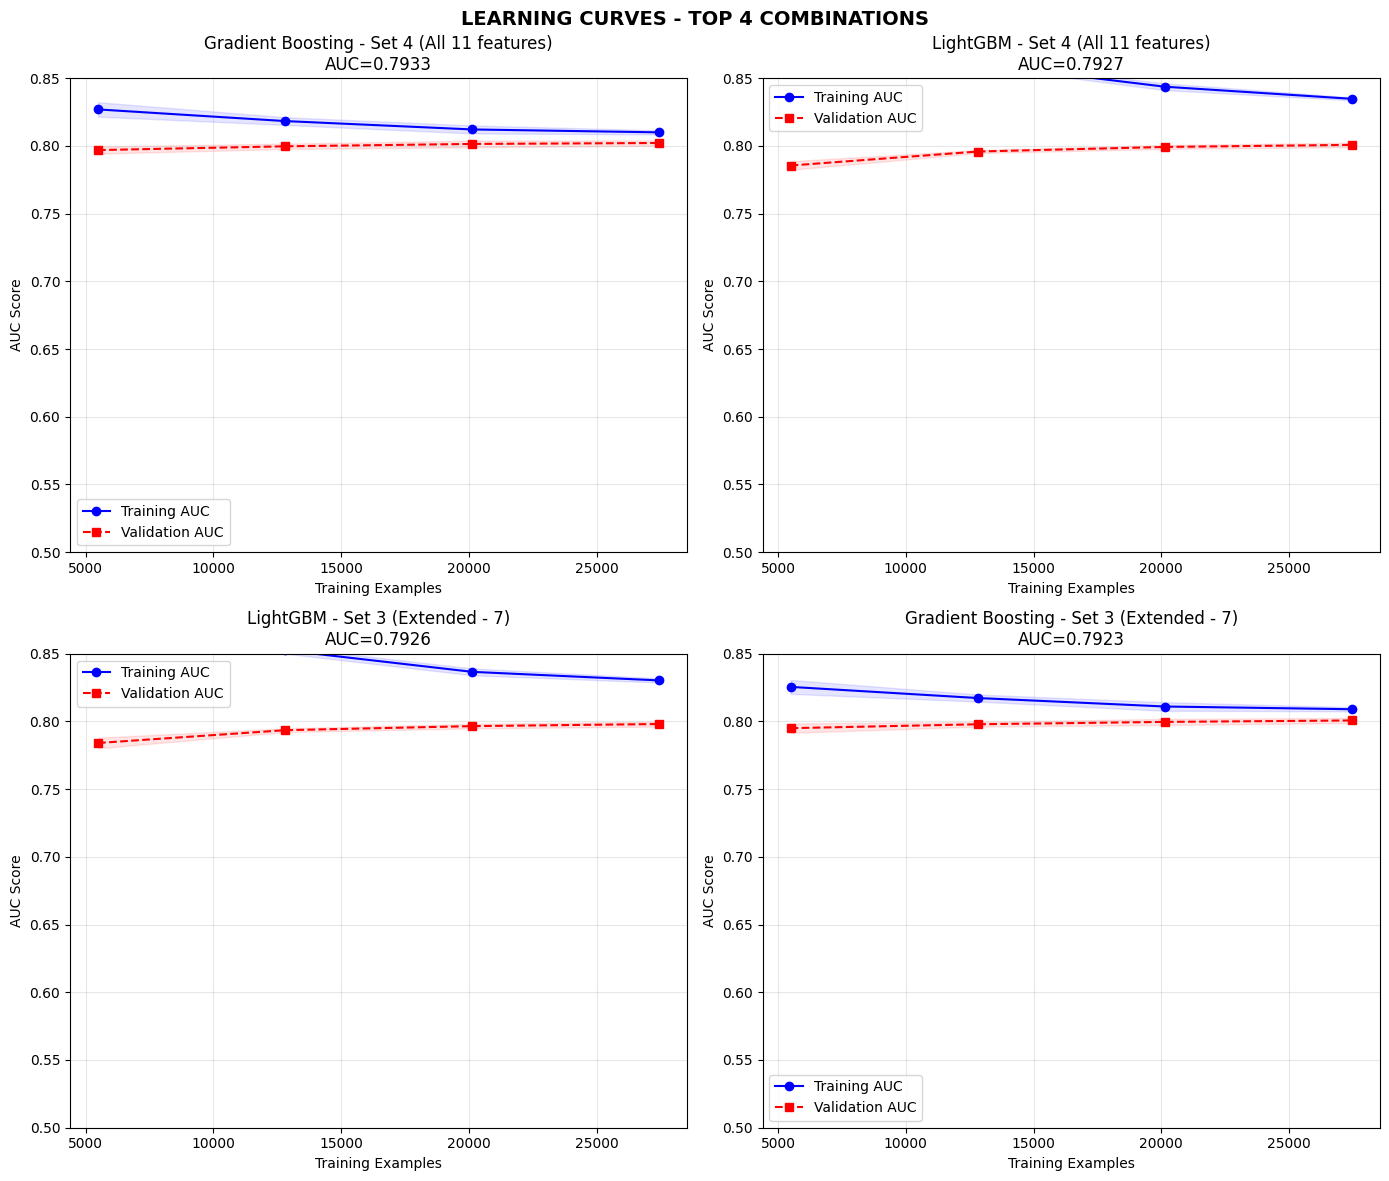

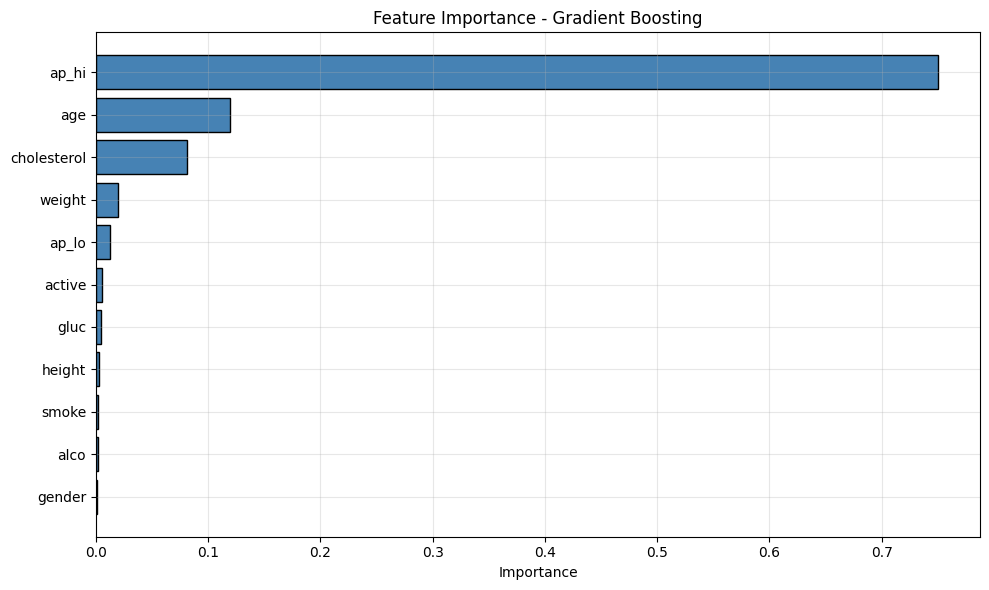


✅ Results saved to: model_results.csv

EXPERIMENTS COMPLETED SUCCESSFULLY


In [ ]:
# ============================================================================
# COMPLETE MODEL TRAINING WITH KNN AND DECISION TREE - with HYPERPARAMETER TUNING
# Cardiovascular Disease Dataset (Kaggle)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             average_precision_score, matthews_corrcoef)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.base import clone
import time
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CLASS: DataLoader
# ============================================================================

class DataLoader:
    def __init__(self, file_path):
        self.file_path = file_path
        self.df = None

    def load_data(self):
        self.df = pd.read_csv(self.file_path)
        return self.df

    def get_info(self):
        print("=" * 80)
        print("DATASET INFORMATION")
        print("=" * 80)
        print(f"Shape: {self.df.shape[0]:,} rows, {self.df.shape[1]} columns")
        print(f"\nTarget distribution:")
        print(self.df['cardio'].value_counts())
        print(self.df['cardio'].value_counts(normalize=True) * 100)

# ============================================================================
# CLASS: FeatureEngineer
# ============================================================================

class FeatureEngineer:
    def __init__(self, df):
        self.df = df.copy()

    def add_bmi(self):
        self.df['bmi'] = self.df['weight'] / ((self.df['height'] / 100) ** 2)
        return self

    def get_data(self):
        return self.df

# ============================================================================
# CLASS: ModelTrainer
# ============================================================================

class ModelTrainer:
    def __init__(self, df, feature_sets, algorithms, random_state=42, test_size=0.2, tune_hyperparams=False):
        self.df = df
        self.feature_sets = feature_sets
        self.algorithms = algorithms
        self.random_state = random_state
        self.test_size = test_size
        self.tune_hyperparams = tune_hyperparams
        self.splits = {}
        self.results = []
        self.trained_models = {}
        self.best_combination = None

    def prepare_splits(self):
        for set_name, features in self.feature_sets.items():
            X = self.df[features]
            y = self.df['cardio']
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=self.test_size, random_state=self.random_state, stratify=y
            )
            self.splits[set_name] = {
                'X_train': X_train,
                'X_test': X_test,
                'y_train': y_train,
                'y_test': y_test,
                'features': features
            }
        return self

    def train_all(self):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)

        for set_name, split in self.splits.items():
            X_train = split['X_train']
            X_test = split['X_test']
            y_train = split['y_train']
            y_test = split['y_test']
            features = split['features']

            print(f"\n{'─'*80}")
            print(f"FEATURE SET: {set_name}")
            print(f"Features ({len(features)}): {features}")
            print(f"{'─'*80}")
            print(f"Training: {X_train.shape[0]:,} samples")
            print(f"Testing: {X_test.shape[0]:,} samples")

            for name, model in self.algorithms.items():
                print(f"\nTraining {name}...", end=" ")
                start_time = time.time()

                # Clone model to avoid feature name issues
                model_clone = clone(model)

                # Handle KNN (needs scaling)
                if name == 'KNN':
                    scaler = StandardScaler()
                    X_train_scaled = scaler.fit_transform(X_train)
                    X_test_scaled = scaler.transform(X_test)

                    if self.tune_hyperparams:
                        param_grid = {
                            'n_neighbors': [3, 5, 7, 9, 11, 15, 21],
                            'weights': ['uniform', 'distance'],
                            'metric': ['euclidean', 'manhattan']
                        }
                        grid_search = GridSearchCV(model_clone, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
                        grid_search.fit(X_train_scaled, y_train)
                        best_model = grid_search.best_estimator_
                        best_params = grid_search.best_params_
                    else:
                        best_model = model_clone
                        best_params = "Default parameters"
                        best_model.fit(X_train_scaled, y_train)

                    y_pred = best_model.predict(X_test_scaled)
                    y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

                elif name == 'Decision Tree':
                    if self.tune_hyperparams:
                        param_grid = {
                            'max_depth': [3, 5, 7, 10, 15, None],
                            'min_samples_split': [2, 5, 10, 20],
                            'min_samples_leaf': [1, 2, 5, 10],
                            'criterion': ['gini', 'entropy']
                        }
                        grid_search = GridSearchCV(model_clone, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
                        grid_search.fit(X_train, y_train)
                        best_model = grid_search.best_estimator_
                        best_params = grid_search.best_params_
                    else:
                        best_model = model_clone
                        best_params = "Default parameters"
                        best_model.fit(X_train, y_train)

                    y_pred = best_model.predict(X_test)
                    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

                else:
                    # Tree-based models (no scaling needed)
                    best_model = model_clone
                    best_params = "Default parameters"
                    best_model.fit(X_train, y_train)
                    y_pred = best_model.predict(X_test)
                    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

                train_time = time.time() - start_time

                accuracy = accuracy_score(y_test, y_pred)
                precision = precision_score(y_test, y_pred)
                recall = recall_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred)
                auc = roc_auc_score(y_test, y_pred_proba)
                mcc = matthews_corrcoef(y_test, y_pred)
                ap = average_precision_score(y_test, y_pred_proba)

                tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                npv = tn / (tn + fn) if (tn + fn) > 0 else 0

                cv_scores = cross_val_score(best_model, X_train_scaled if name == 'KNN' else X_train, y_train, cv=cv, scoring='roc_auc')

                self.results.append({
                    'Feature_Set': set_name,
                    'Algorithm': name,
                    'N_Features': len(features),
                    'Accuracy': accuracy,
                    'Precision': precision,
                    'Recall': recall,
                    'Specificity': specificity,
                    'NPV': npv,
                    'F1_Score': f1,
                    'AUC': auc,
                    'MCC': mcc,
                    'AP': ap,
                    'CV_Mean': cv_scores.mean(),
                    'CV_Std': cv_scores.std(),
                    'Train_Time': train_time,
                    'Best_Params': str(best_params),
                    'TP': tp,
                    'TN': tn,
                    'FP': fp,
                    'FN': fn
                })

                key = f"{name}_{set_name}"
                self.trained_models[key] = best_model

                print(f"Done!")
                print(f"  AUC: {auc:.4f} | Acc: {accuracy:.4f} | F1: {f1:.4f} | Time: {train_time:.2f}s")

        return self

    def get_best(self):
        best = max(self.results, key=lambda x: x['AUC'])
        self.best_combination = best
        return best

    def get_results_df(self):
        return pd.DataFrame(self.results)

    def get_pivot_table(self, metric='AUC'):
        df = self.get_results_df()
        return df.pivot(index='Feature_Set', columns='Algorithm', values=metric)

# ============================================================================
# CLASS: ModelEvaluator
# ============================================================================

class ModelEvaluator:
    def __init__(self, trainer):
        self.trainer = trainer
        self.results_df = trainer.get_results_df()
        self.best = trainer.get_best()
        self.best_key = f"{self.best['Algorithm']}_{self.best['Feature_Set']}"
        self.best_model = trainer.trained_models[self.best_key]
        self.best_split = trainer.splits[self.best['Feature_Set']]

    def print_summary(self):
        print("\n" + "=" * 80)
        print("BEST COMBINATION")
        print("=" * 80)
        print(f"Feature Set: {self.best['Feature_Set']}")
        print(f"Algorithm: {self.best['Algorithm']}")
        print(f"AUC: {self.best['AUC']:.4f}")
        print(f"Accuracy: {self.best['Accuracy']:.4f} ({self.best['Accuracy']*100:.2f}%)")
        print(f"F1 Score: {self.best['F1_Score']:.4f}")
        print(f"CV AUC: {self.best['CV_Mean']:.4f} (+/- {self.best['CV_Std']:.4f})")
        print(f"Training Time: {self.best['Train_Time']:.2f}s")
        print(f"Best Params: {self.best['Best_Params']}")
        print(f"Features: {self.trainer.splits[self.best['Feature_Set']]['features']}")

    def print_pivot_tables(self):
        print("\n" + "=" * 80)
        print("RESULTS SUMMARY")
        print("=" * 80)

        metrics = ['AUC', 'Accuracy', 'F1_Score', 'Train_Time']
        for metric in metrics:
            pivot = self.trainer.get_pivot_table(metric)
            print(f"\n{metric} by Feature Set and Algorithm:")
            print("-" * 60)
            print(pivot.round(4))

    def print_overfitting_analysis(self):
        print("\n" + "=" * 80)
        print("OVERFITTING ANALYSIS")
        print("=" * 80)
        print("\nComparing CV AUC vs Test AUC:")
        print("-" * 80)
        print(f"{'Feature Set':<25} {'Algorithm':<20} {'CV AUC':<12} {'Test AUC':<12} {'Diff':<10} {'Risk':<10}")
        print("-" * 80)

        for _, row in self.results_df.iterrows():
            diff = row['CV_Mean'] - row['AUC']
            risk = "High" if abs(diff) > 0.05 else "Moderate" if abs(diff) > 0.025 else "Low"
            print(f"{row['Feature_Set']:<25} {row['Algorithm']:<20} {row['CV_Mean']:.4f}       {row['AUC']:.4f}       {diff:+.4f}    {risk}")

    def print_classification_report(self):
        print("\n" + "=" * 80)
        print("DETAILED CLASSIFICATION REPORT - BEST MODEL")
        print("=" * 80)

        X_test = self.best_split['X_test']
        y_test = self.best_split['y_test']

        # Handle KNN scaling
        if self.best['Algorithm'] == 'KNN':
            scaler = StandardScaler()
            X_train = self.trainer.splits[self.best['Feature_Set']]['X_train']
            scaler.fit(X_train)
            X_test_scaled = scaler.transform(X_test)
            y_pred = self.best_model.predict(X_test_scaled)
        else:
            y_pred = self.best_model.predict(X_test)

        print(f"\n{'─'*60}")
        print(f"Model: {self.best['Algorithm']}")
        print(f"Feature Set: {self.best['Feature_Set']}")
        print(f"{'─'*60}")

        print("\nClassification Report:")
        print("-" * 50)
        print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Diseased (1)']))

        tn, fp, fn, tp = self.best['TN'], self.best['FP'], self.best['FN'], self.best['TP']
        print("\nConfusion Matrix:")
        print("-" * 40)
        print(f"  True Negatives:  {tn:6,}  (Correctly predicted Healthy)")
        print(f"  False Positives: {fp:6,}  (Wrongly predicted Diseased)")
        print(f"  False Negatives: {fn:6,}  (Wrongly predicted Healthy)")
        print(f"  True Positives:  {tp:6,}  (Correctly predicted Diseased)")

        print("\nMetrics Summary:")
        print("-" * 40)
        print(f"  Specificity: {self.best['Specificity']:.4f} ({self.best['Specificity']*100:.2f}%)")
        print(f"  NPV: {self.best['NPV']:.4f} ({self.best['NPV']*100:.2f}%)")
        print(f"  MCC: {self.best['MCC']:.4f}")
        print(f"  AP: {self.best['AP']:.4f}")

    def print_feature_ranking(self):
        print("\n" + "=" * 80)
        print("FEATURE SET RANKING (Average AUC across all algorithms)")
        print("=" * 80)

        avg_auc = self.results_df.groupby('Feature_Set')['AUC'].mean().sort_values(ascending=False)
        for set_name, avg in avg_auc.items():
            print(f"  {set_name}: {avg:.4f}")

    def print_final_ranking(self):
        print("\n" + "=" * 80)
        print("FINAL RANKING (by AUC)")
        print("=" * 80)

        top_10 = self.results_df.sort_values('AUC', ascending=False).head(10)
        for i, (_, row) in enumerate(top_10.iterrows()):
            medal = "🥇" if i == 0 else "🥈" if i == 1 else "🥉" if i == 2 else "  "
            print(f"{medal} {i+1:2d}. {row['Algorithm']:<18} | {row['Feature_Set']:<25} | AUC={row['AUC']:.4f} | Acc={row['Accuracy']:.4f}")

    def plot_roc_curves(self):
        fig, ax = plt.subplots(figsize=(10, 8))
        colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']

        for idx, (set_name, split) in enumerate(self.trainer.splits.items()):
            set_results = self.results_df[self.results_df['Feature_Set'] == set_name]
            best_in_set = set_results.loc[set_results['AUC'].idxmax()]
            key = f"{best_in_set['Algorithm']}_{set_name}"
            model = self.trainer.trained_models[key]

            # IMPORTANT: Use the correct test data for this feature set
            X_test = split['X_test']
            y_test = split['y_test']

            # Handle KNN scaling
            if best_in_set['Algorithm'] == 'KNN':
                scaler = StandardScaler()
                X_train = self.trainer.splits[set_name]['X_train']
                scaler.fit(X_train)
                X_test_scaled = scaler.transform(X_test)
                y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
            else:
                y_pred_proba = model.predict_proba(X_test)[:, 1]

            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            auc = roc_auc_score(y_test, y_pred_proba)

            label = f"{set_name.replace('Set ', '')} ({best_in_set['Algorithm'][:10]}) AUC={auc:.4f}"
            ax.plot(fpr, tpr, color=colors[idx % len(colors)], lw=2, label=label)

        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_title('ROC Curves - Best Model per Feature Set', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('/content/roc_curves.png', dpi=150)
        plt.show()

    def plot_confusion_matrix(self):
        X_test = self.best_split['X_test']
        y_test = self.best_split['y_test']

        if self.best['Algorithm'] == 'KNN':
            scaler = StandardScaler()
            X_train = self.trainer.splits[self.best['Feature_Set']]['X_train']
            scaler.fit(X_train)
            X_test_scaled = scaler.transform(X_test)
            y_pred = self.best_model.predict(X_test_scaled)
        else:
            y_pred = self.best_model.predict(X_test)

        cm = confusion_matrix(y_test, y_pred)

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Healthy', 'Diseased'],
                    yticklabels=['Healthy', 'Diseased'])
        ax.set_title(f'Confusion Matrix - Best Model\n{self.best["Algorithm"]} on {self.best["Feature_Set"]}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        plt.tight_layout()
        plt.savefig('/content/confusion_matrix.png', dpi=150)
        plt.show()

    def plot_learning_curves(self):
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))

        top_4 = self.results_df.sort_values('AUC', ascending=False).head(4)

        for i, (_, row) in enumerate(top_4.iterrows()):
            ax = axes[i // 2, i % 2]
            key = f"{row['Algorithm']}_{row['Feature_Set']}"
            model = self.trainer.trained_models[key]

            X_train = self.trainer.splits[row['Feature_Set']]['X_train']
            y_train = self.trainer.splits[row['Feature_Set']]['y_train']

            # Handle KNN scaling
            if row['Algorithm'] == 'KNN':
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                train_sizes, train_scores, test_scores = learning_curve(
                    model, X_train_scaled, y_train, cv=2, n_jobs=-1,
                    train_sizes=np.linspace(0.2, 1.0, 4),
                    scoring='roc_auc', random_state=42
                )
            else:
                train_sizes, train_scores, test_scores = learning_curve(
                    model, X_train, y_train, cv=2, n_jobs=-1,
                    train_sizes=np.linspace(0.2, 1.0, 4),
                    scoring='roc_auc', random_state=42
                )

            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            test_mean = np.mean(test_scores, axis=1)
            test_std = np.std(test_scores, axis=1)

            ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
            ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')
            ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training AUC')
            ax.plot(train_sizes, test_mean, 's--', color='red', label='Validation AUC')
            ax.set_xlabel('Training Examples')
            ax.set_ylabel('AUC Score')
            ax.set_title(f"{row['Algorithm']} - {row['Feature_Set']}\nAUC={row['AUC']:.4f}")
            ax.legend()
            ax.grid(True, alpha=0.3)
            ax.set_ylim(0.5, 0.85)

        plt.suptitle('LEARNING CURVES - TOP 4 COMBINATIONS', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('/content/learning_curves.png', dpi=150)
        plt.show()

    def plot_feature_importance(self):
        if hasattr(self.best_model, 'feature_importances_'):
            features = self.trainer.splits[self.best['Feature_Set']]['features']
            importances = self.best_model.feature_importances_

            fig, ax = plt.subplots(figsize=(10, 6))
            imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
            imp_df = imp_df.sort_values('Importance', ascending=True)
            ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue', edgecolor='black')
            ax.set_xlabel('Importance')
            ax.set_title(f'Feature Importance - {self.best["Algorithm"]}')
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('/content/feature_importance.png', dpi=150)
            plt.show()

    def run_all_visualizations(self):
        self.plot_roc_curves()
        self.plot_confusion_matrix()
        self.plot_learning_curves()
        self.plot_feature_importance()

    def save_results(self):
        self.results_df.to_csv('/content/model_results.csv', index=False)
        print("\n✅ Results saved to: model_results.csv")

# ============================================================================
# CLASS: ExperimentRunner (Main Controller)
# ============================================================================

class ExperimentRunner:
    def __init__(self, file_path, tune_hyperparams=False):
        self.file_path = file_path
        self.df = None
        self.trainer = None
        self.evaluator = None
        self.tune_hyperparams = tune_hyperparams

    def run(self):
        print("=" * 80)
        print("CARDIOVASCULAR DISEASE - COMPLETE MODEL TRAINING EXPERIMENTS")
        print(f"Hyperparameter Tuning: {'ENABLED' if self.tune_hyperparams else 'DISABLED'}")
        print("=" * 80)

        # Step 1: Load Data
        loader = DataLoader(self.file_path)
        self.df = loader.load_data()
        loader.get_info()

        # Step 2: Feature Engineering
        engineer = FeatureEngineer(self.df)
        engineer.add_bmi()
        self.df = engineer.get_data()
        print(f"\n✅ BMI added to dataset")
        print(f"Final dataset: {self.df.shape[0]:,} rows, {self.df.shape[1]} columns")

        # Step 3: Define Feature Sets
        feature_sets = {
            'Set 1 (Minimal - 3)': ['ap_hi', 'age', 'bmi'],
            'Set 2 (Medium - 5)': ['ap_hi', 'age', 'bmi', 'ap_lo', 'cholesterol'],
            'Set 3 (Extended - 7)': ['ap_hi', 'age', 'bmi', 'ap_lo', 'cholesterol', 'active', 'smoke'],
            'Set 4 (All 11 features)': ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                                        'cholesterol', 'gluc', 'smoke', 'alco', 'active']
        }

        # Step 4: Define Algorithms (including KNN and Decision Tree)
        algorithms = {
            'KNN': KNeighborsClassifier(),
            'Decision Tree': DecisionTreeClassifier(random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(random_state=42),
            'XGBoost': XGBClassifier(random_state=42, n_jobs=-1,
                                     use_label_encoder=False, eval_metric='logloss'),
            'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
            'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1)
        }

        # Step 5: Train Models
        print("\n" + "=" * 80)
        print("TRAINING MODELS")
        print("=" * 80)

        self.trainer = ModelTrainer(
            self.df,
            feature_sets,
            algorithms,
            tune_hyperparams=self.tune_hyperparams
        )
        self.trainer.prepare_splits()
        self.trainer.train_all()

        # Step 6: Evaluate
        self.evaluator = ModelEvaluator(self.trainer)
        self.evaluator.print_summary()
        self.evaluator.print_pivot_tables()
        self.evaluator.print_overfitting_analysis()
        self.evaluator.print_classification_report()
        self.evaluator.print_feature_ranking()
        self.evaluator.print_final_ranking()

        # Step 7: Visualizations
        print("\n" + "=" * 80)
        print("GENERATING VISUALIZATIONS")
        print("=" * 80)
        self.evaluator.run_all_visualizations()

        # Step 8: Save Results
        self.evaluator.save_results()

        print("\n" + "=" * 80)
        print("EXPERIMENTS COMPLETED SUCCESSFULLY")
        print("=" * 80)

        return self.trainer, self.evaluator

# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    runner = ExperimentRunner('/content/cardio_train_cleaned.csv', tune_hyperparams=True)
    trainer, evaluator = runner.run()